# GasBrineBench: a tour

[GasBrineBench](https://github.com/jmoortgat/GasBrineBench) is a curated,
quality-coded benchmark of experimental thermodynamic data for **gas-brine
systems**: gas solubility, brine density, water activity, water content of the
gas phase, and enthalpy of dissolution, in single- and mixed-salt aqueous
electrolyte solutions. 5,846 rows, 82 published sources, seven gases, six
ions, 273-623 K, 0.1-3,500 bar.

This notebook does two things:

1. **Shows the `gasbrinebench` package** -- loading, filtering, derived
   quantities, inventory tables, export -- in about five minutes of reading.
2. **Shows what is in the data**: where the coverage is, how the quality codes
   fall, and the physical trends the database was built to constrain.

It runs from a fresh clone with nothing but `pandas` and `matplotlib`
installed, and it writes nothing into the repository.

**On the shaded bands.** Two figures below draw a shaded envelope around the
measurements that different laboratories reported at matched conditions. They
are there to show the shape of the situation at a glance. They are not
quantified here, and nothing in this notebook computes how far apart the
laboratories are or compares that with the uncertainties the original authors
stated. That analysis is the subject of a benchmark paper in preparation and
belongs there, not in a tour of the data.

---

## Setting up

The package is imported straight from the clone -- there is nothing to
install. The cell below walks up from the working directory until it finds the
repository root, so the notebook runs from `notebooks/`, from the root, or
from anywhere else inside the clone.

In [1]:
import sys
from pathlib import Path

root = Path.cwd().resolve()
while not (root / "gasbrinebench").is_dir():
    if root == root.parent:
        raise RuntimeError(
            "run this notebook from inside a GasBrineBench clone"
        )
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
import pandas as pd

import gasbrinebench as gbb

print("repository :", root.name + "/")
print("package    :", gbb.__version__)
print("data       :", gbb.data_dir().relative_to(root))
print("families   :", ", ".join(gbb.available_families()))

repository : GasBrineBench/
package    : 0.9.0-pre
data       : data
families   : solubility, y_h2o, rho, phi_osm, dh_sol, psat_ratio, eps_r


### Figure style

One style block for the whole notebook. Every series is distinguished by
**colour, line style and marker together**, never by colour alone, and the
palette is Wong's eight-colour colourblind-safe set. Text is bold, axes are
black and heavy, and figures render at 300 dpi so they stay legible printed
small. Figures carry no titles -- the explanation is in the markdown cell
above each one.

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.size": 14, "axes.labelsize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 11,
    "font.weight": "bold", "axes.labelweight": "bold",
    "axes.linewidth": 1.8, "axes.edgecolor": "black",
    "xtick.major.width": 1.8, "ytick.major.width": 1.8,
    "xtick.minor.width": 1.2, "ytick.minor.width": 1.2,
    "xtick.major.size": 6, "ytick.major.size": 6,
    "xtick.color": "black", "ytick.color": "black",
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "lines.linewidth": 2.2, "lines.markersize": 7,
    "lines.markeredgewidth": 1.4,
    "legend.frameon": True, "legend.edgecolor": "black",
    "legend.framealpha": 1.0,
    "figure.figsize": (6.6, 4.6),
    # 300 dpi for both the inline renders committed in this notebook (the
    # inline backend uses figure.dpi) and anything you fig.savefig() yourself.
    "figure.dpi": 300, "savefig.dpi": 300, "savefig.bbox": "tight",
})

# Wong (2011) colourblind-safe palette; yellow and black placed last so that
# short series get the high-contrast colours.
WONG = ["#000000", "#E69F00", "#56B4E9", "#009E73",
        "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]
ORDER = [1, 2, 3, 5, 6, 7, 4, 0]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1, 1, 1)), (0, (5, 1))]
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]
HATCHES = ["", "///", "\\\\\\", "xxx", "...", "+++", "ooo"]


def series_style(i):
    """Colour, line style and marker for series i -- never colour alone."""
    return dict(color=WONG[ORDER[i % len(ORDER)]],
                linestyle=LINESTYLES[i % len(LINESTYLES)],
                marker=MARKERS[i % len(MARKERS)])


def label(ax, x, y):
    """Short axis labels, bold tick text."""
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")
    return ax


GAS_LABEL = {"co2": "CO$_2$", "ch4": "CH$_4$", "h2": "H$_2$", "n2": "N$_2$",
             "o2": "O$_2$", "c2h6": "C$_2$H$_6$", "c3h8": "C$_3$H$_8$"}
SALT_LABEL = {"Na-Cl": "NaCl", "Cl-K": "KCl", "Cl-Ca": "CaCl$_2$",
              "Cl-Mg": "MgCl$_2$", "Na-SO4": "Na$_2$SO$_4$",
              "water": "water"}

---

## 1. Loading

`gbb.load()` reads any family, or all of them, and hands back a tidy
DataFrame. It applies the two conventions that a hand-rolled `read_csv` gets
wrong: `keep_default_na=False`, so the legitimately empty `gas` cell of a
brine-only row stays an empty string instead of becoming `NaN`; and a
subsequent numeric coercion, so the genuinely blank cells (`P_bar` on the
`psat_ratio` rows, `uncertainty` wherever the source stated none) become
`NaN` instead of the string `''`.

**One default is worth knowing about.** `load()` drops the 144 rows tagged
`lle-regime`. Those are propane points measured below propane's critical
temperature at or above its own vapour pressure, so the hydrocarbon-rich
phase is a *liquid*: they are liquid-liquid mutual solubilities, not gas
solubilities. They are good data about a different property, and scoring them
as gas solubility is a category error. Pass `exclude_tags=None` to get all
5,846 rows.

In [3]:
df = gbb.load()                       # 5,702 rows: the gas-brine scope
everything = gbb.load(exclude_tags=None)   # all 5,846 rows as stored

print(f"default loader : {len(df):,} rows")
print(f"every row      : {len(everything):,} rows")
print(f"difference     : {len(everything) - len(df)} rows tagged lle-regime, "
      f"all {set(everything.loc[everything['tag'] == 'lle-regime', 'gas'])}")

df.head(3)

default loader : 5,702 rows
every row      : 5,846 rows
difference     : 144 rows tagged lle-regime, all {'c3h8'}


,dataset_id,source,gas,property,T_K,P_bar,m_Na,m_Cl,m_K,m_Ca,...,m_SO4,value,uncertainty,quality,tag,family,ionic_strength,total_molality,salt_system,salt_system_kind
0,co2_part1,TEYMOURI(2017),co2,xc_saltfree,323.0,122.76,1.9,1.9,0.0,0.0,...,0.0,0.013400,NaN,T,fit-eligible,solubility,1.9,3.8,Na-Cl,single-salt
1,co2_part1,TEYMOURI(2017),co2,solubility_molality,323.0,122.76,1.9,1.9,0.0,0.0,...,0.0,0.753915,NaN,T,fit-eligible,solubility,1.9,3.8,Na-Cl,single-salt
2,co2_part1,TEYMOURI(2017),co2,xc_saltfree,323.0,259.31,1.9,1.9,0.0,0.0,...,0.0,0.016300,NaN,T,fit-eligible,solubility,1.9,3.8,Na-Cl,single-salt


In [4]:
# The schema, plus the derived columns load() attaches.
print("schema   :", ", ".join(gbb.COLUMNS))
print("derived  : family, ionic_strength, total_molality, salt_system, "
      "salt_system_kind")
df.dtypes.to_frame("dtype").T

schema   : dataset_id, source, gas, property, T_K, P_bar, m_Na, m_Cl, m_K, m_Ca, m_Mg, m_SO4, value, uncertainty, quality, tag
derived  : family, ionic_strength, total_molality, salt_system, salt_system_kind


,dataset_id,source,gas,property,T_K,P_bar,m_Na,m_Cl,m_K,m_Ca,...,m_SO4,value,uncertainty,quality,tag,family,ionic_strength,total_molality,salt_system,salt_system_kind
dtype,object,object,object,object,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,object,object,object,float64,float64,object,object


## 2. What is in the database

`gbb.inventory()` summarises any selection: rows, distinct sources, gases,
T and P range, and the R/T/U quality mix. Group it on whatever column you
care about.

In [5]:
gbb.inventory(everything)

,rows,sources,gases,T_min,T_max,P_min,P_max,R,T,U
family,,,,,,,,,,
dh_sol,22,1,co2,323.1,373.1,20.60,202.4,0,22,0
eps_r,13,1,-,298.2,298.2,1.00,1.0,0,13,0
phi_osm,101,2,-,298.2,373.2,1.00,1.5,75,26,0
psat_ratio,21,1,-,373.2,523.2,NaN,NaN,21,0,0
rho,905,42,-,283.0,473.0,9.00,686.0,0,905,0
solubility,3783,57,"c2h6, c3h8, ch4, co2, h2, n2, o2",273.0,589.0,0.10,1379.0,173,3590,20
y_h2o,1001,26,"c2h6, c3h8, ch4, co2, h2, n2",273.2,623.0,4.25,3500.0,105,870,26


In [6]:
gbb.inventory(everything[everything["gas"] != ""], by="gas")

,rows,sources,gases,T_min,T_max,P_min,P_max,R,T,U
gas,,,,,,,,,,
c2h6,241,5,c2h6,282.9,444.3,3.73,685.00,0,241,0
c3h8,624,4,c3h8,273.2,427.6,0.10,206.84,0,614,10
ch4,720,14,ch4,278.0,523.0,4.20,1379.00,16,702,2
co2,2520,48,co2,278.0,623.0,3.40,3500.00,238,2258,24
h2,437,12,h2,273.0,589.0,3.40,1013.30,24,413,0
n2,176,3,n2,282.9,483.2,4.25,1349.00,0,176,0
o2,88,2,o2,303.3,373.2,30.52,360.63,0,78,10


`gbb.coverage()` lays the same thing out as a rectangle of (gas x salt
system). The zeros matter as much as the counts: they are the holes. Note in
particular that the CO$_2$ solubility family carries no pure-water rows --
its binaries live in the `y_h2o` family instead -- while the hydrocarbon and
H$_2$ blocks are mostly binaries.

In [7]:
gbb.coverage(gbb.load("solubility"))

salt_system,water,Cl-Ca,Cl-K,Cl-K-Ca,Cl-Mg,Mg-SO4,Na-Cl,Na-Cl-Ca,Na-Cl-K,Na-Cl-K-Ca,Na-Cl-K-Ca-Mg,Na-Cl-K-Ca-Mg-SO4,Na-Cl-SO4,Na-SO4
gas,,,,,,,,,,,,,,
c2h6,232,0,0,0,0,0,0,0,0,0,0,0,0,0
c3h8,256,0,0,0,0,0,220,0,0,0,0,0,0,0
ch4,0,39,98,0,9,9,308,0,0,0,0,0,0,6
co2,0,266,186,16,198,0,456,64,56,198,98,164,24,118
h2,326,0,0,0,0,0,102,0,0,0,0,0,0,0
n2,36,0,0,0,0,0,66,0,0,0,0,0,0,0
o2,0,0,0,0,0,0,88,0,0,0,0,0,0,0


And `gbb.sources()` gives one row per contributing source. The `source` cell
is the curation key the transcription carried, not a bibtex key; `SOURCES.md`
maps each one onto its published reference and DOI.

In [8]:
gbb.sources(df).head(10)

,rows,families,gases,T_min,T_max,P_min,P_max
source,,,,,,,
UMANO(1958),270,solubility,c3h8,273.2,298.2,0.10,1.03
SUSAK(1980),264,solubility,ch4,298.0,523.0,68.90,1379.00
TEYMOURI(2017),252,solubility,co2,323.0,423.0,27.86,595.86
LIU_2011,198,solubility,co2,308.0,328.0,13.40,160.20
WANG_2014,128,solubility,co2,318.0,348.0,80.00,110.00
KOBAYASHI(1951),128,solubility,c3h8,288.7,427.6,6.90,206.84
TABASINEJAD(2011),117,y_h2o,"ch4, co2, n2",422.4,483.2,36.70,1349.00
TAKENOUCHI,108,y_h2o,co2,383.0,623.0,100.00,1500.00
ZHAOb(2015),108,solubility,co2,323.0,423.0,150.00,150.00


### Figure 1 -- where the measurements are

Every gas-property row in (T, P), one marker and colour per gas, with the
brine-only rows (density, osmotic coefficient, permittivity) overlaid as
crosses. Pressure is logarithmic because the database spans four decades of
it. The vertical stripes are the round temperatures experimentalists work at;
the propane rows below 1 bar are the sub-atmospheric solubility measurements
of Umano and Hama.

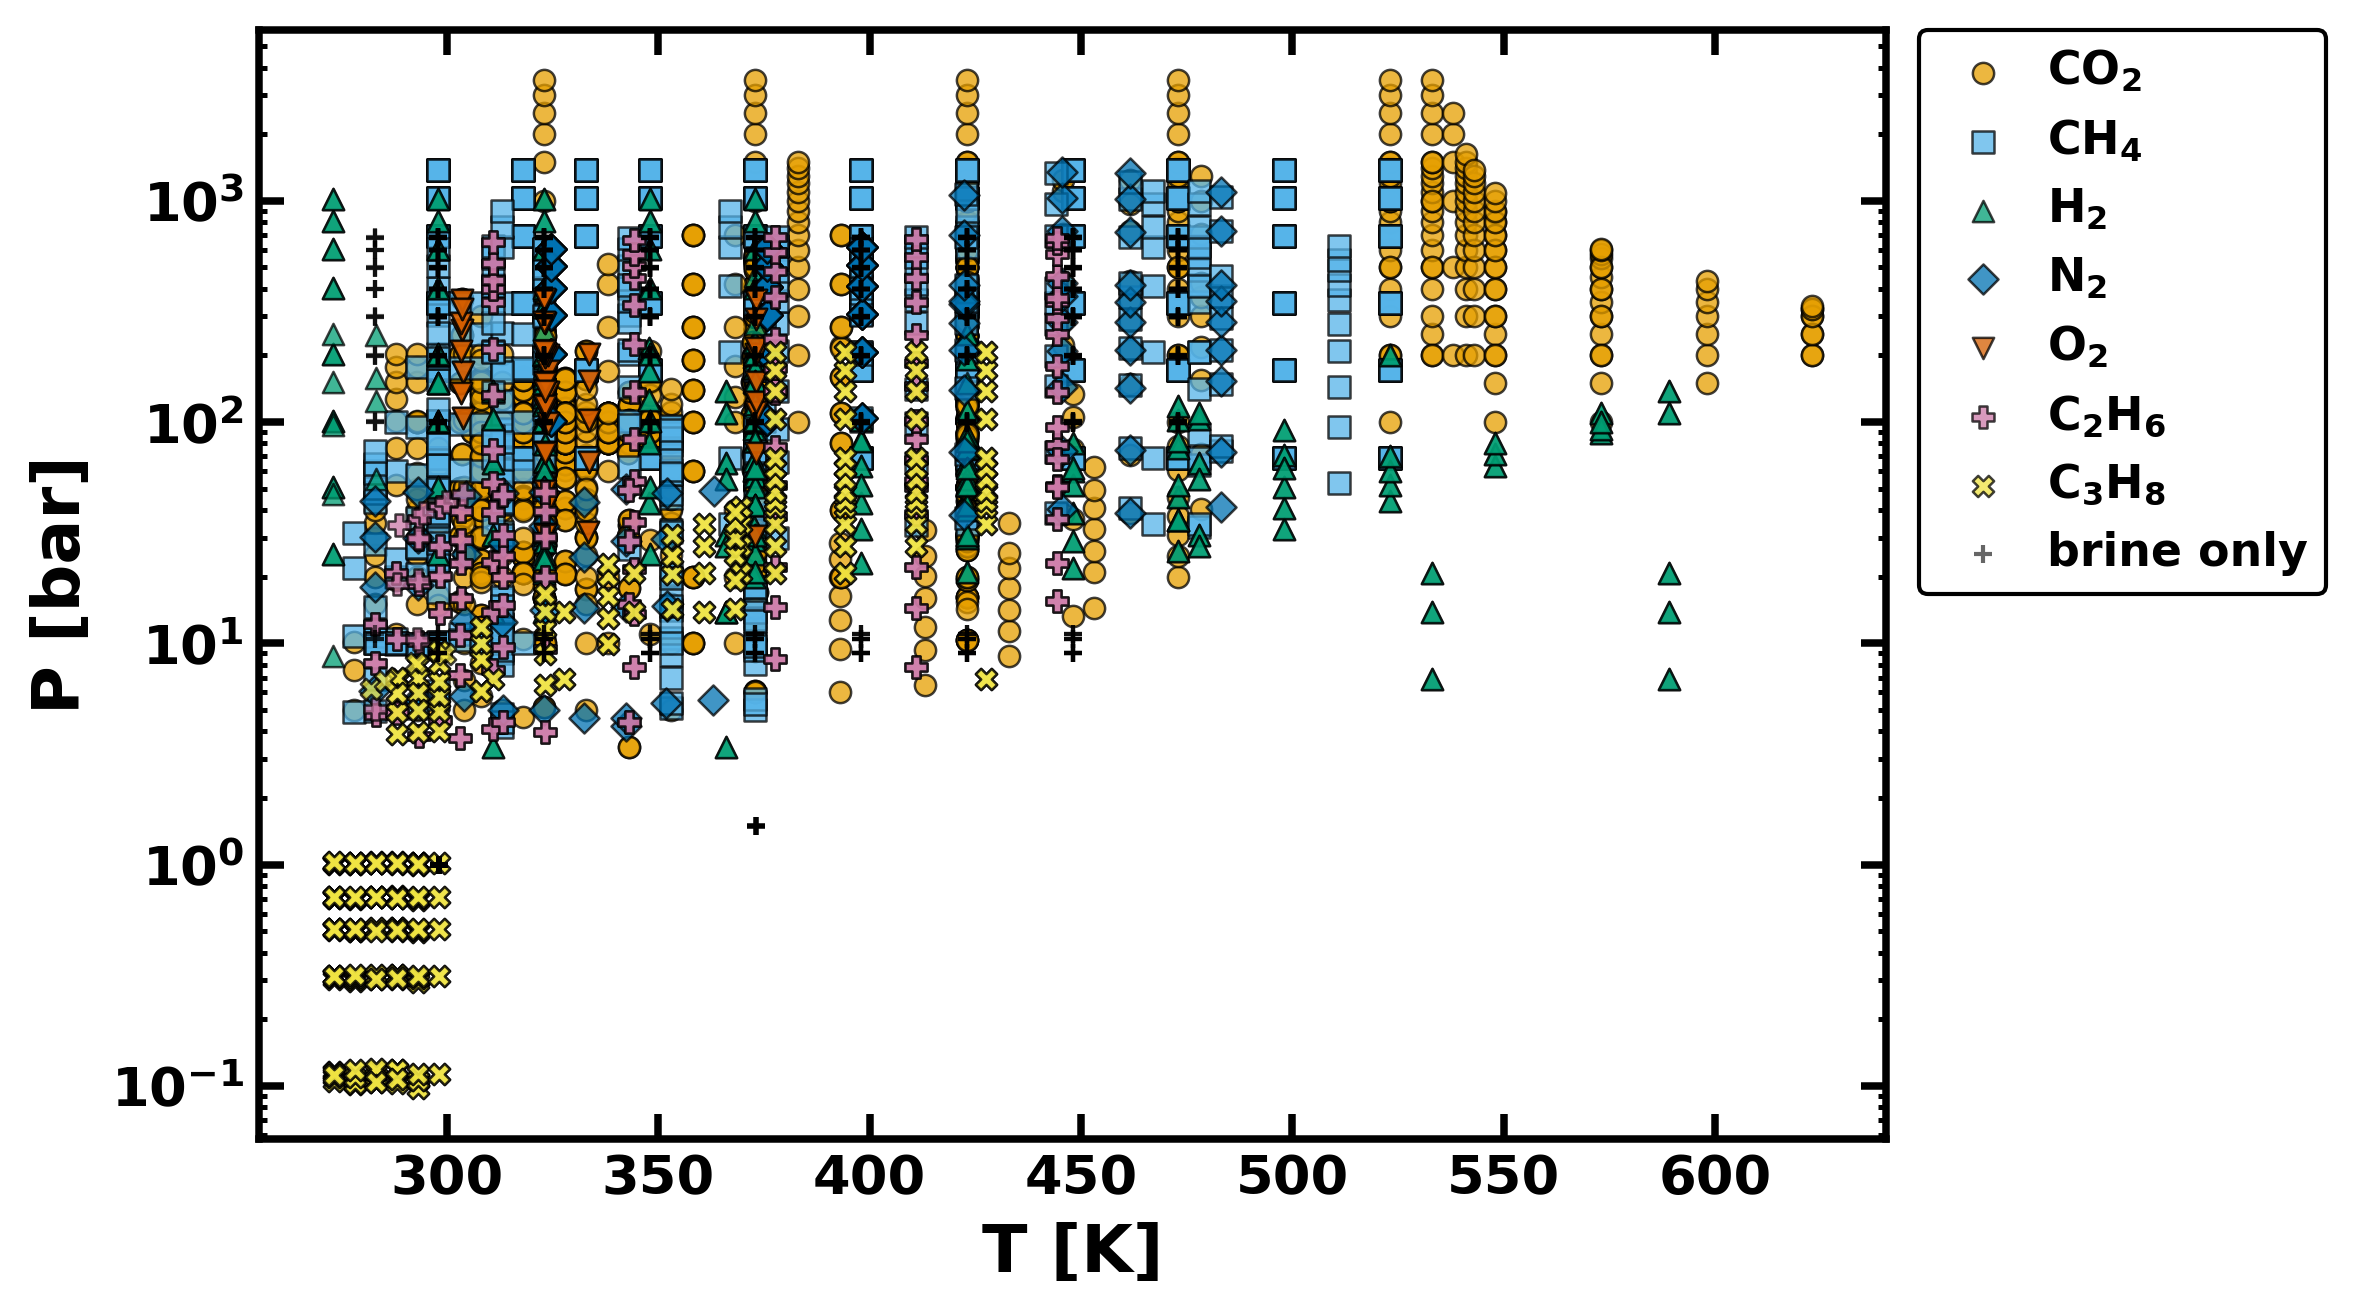

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

gasrows = df[df["gas"] != ""].dropna(subset=["P_bar"])
for i, g in enumerate(["co2", "ch4", "h2", "n2", "o2", "c2h6", "c3h8"]):
    s = gasrows[gasrows["gas"] == g]
    ax.scatter(s["T_K"], s["P_bar"], s=26, marker=MARKERS[i % len(MARKERS)],
               facecolor=WONG[ORDER[i % len(ORDER)]], edgecolor="black",
               linewidth=0.6, alpha=0.75, label=GAS_LABEL[g])

brine = df[df["gas"] == ""].dropna(subset=["P_bar"])
ax.scatter(brine["T_K"], brine["P_bar"], s=20, marker="+", color="black",
           linewidth=1.0, alpha=0.6, label="brine only")

ax.set_yscale("log")
label(ax, "T [K]", "P [bar]")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0,
          handletextpad=0.4)
plt.show()

### Figure 2 -- rows per property family (a) and per gas (b)

Panel (a) is on a log axis because the families differ by two and a half
orders of magnitude: solubility dominates, and the small families
(`dh_sol`, `psat_ratio`, `eps_r`) are single-source sets that anchor
particular parts of the model rather than carry statistical weight. Panel (b)
counts every row that names a gas, so a solubility point appears twice where
the source reported both a molality and a mole fraction.

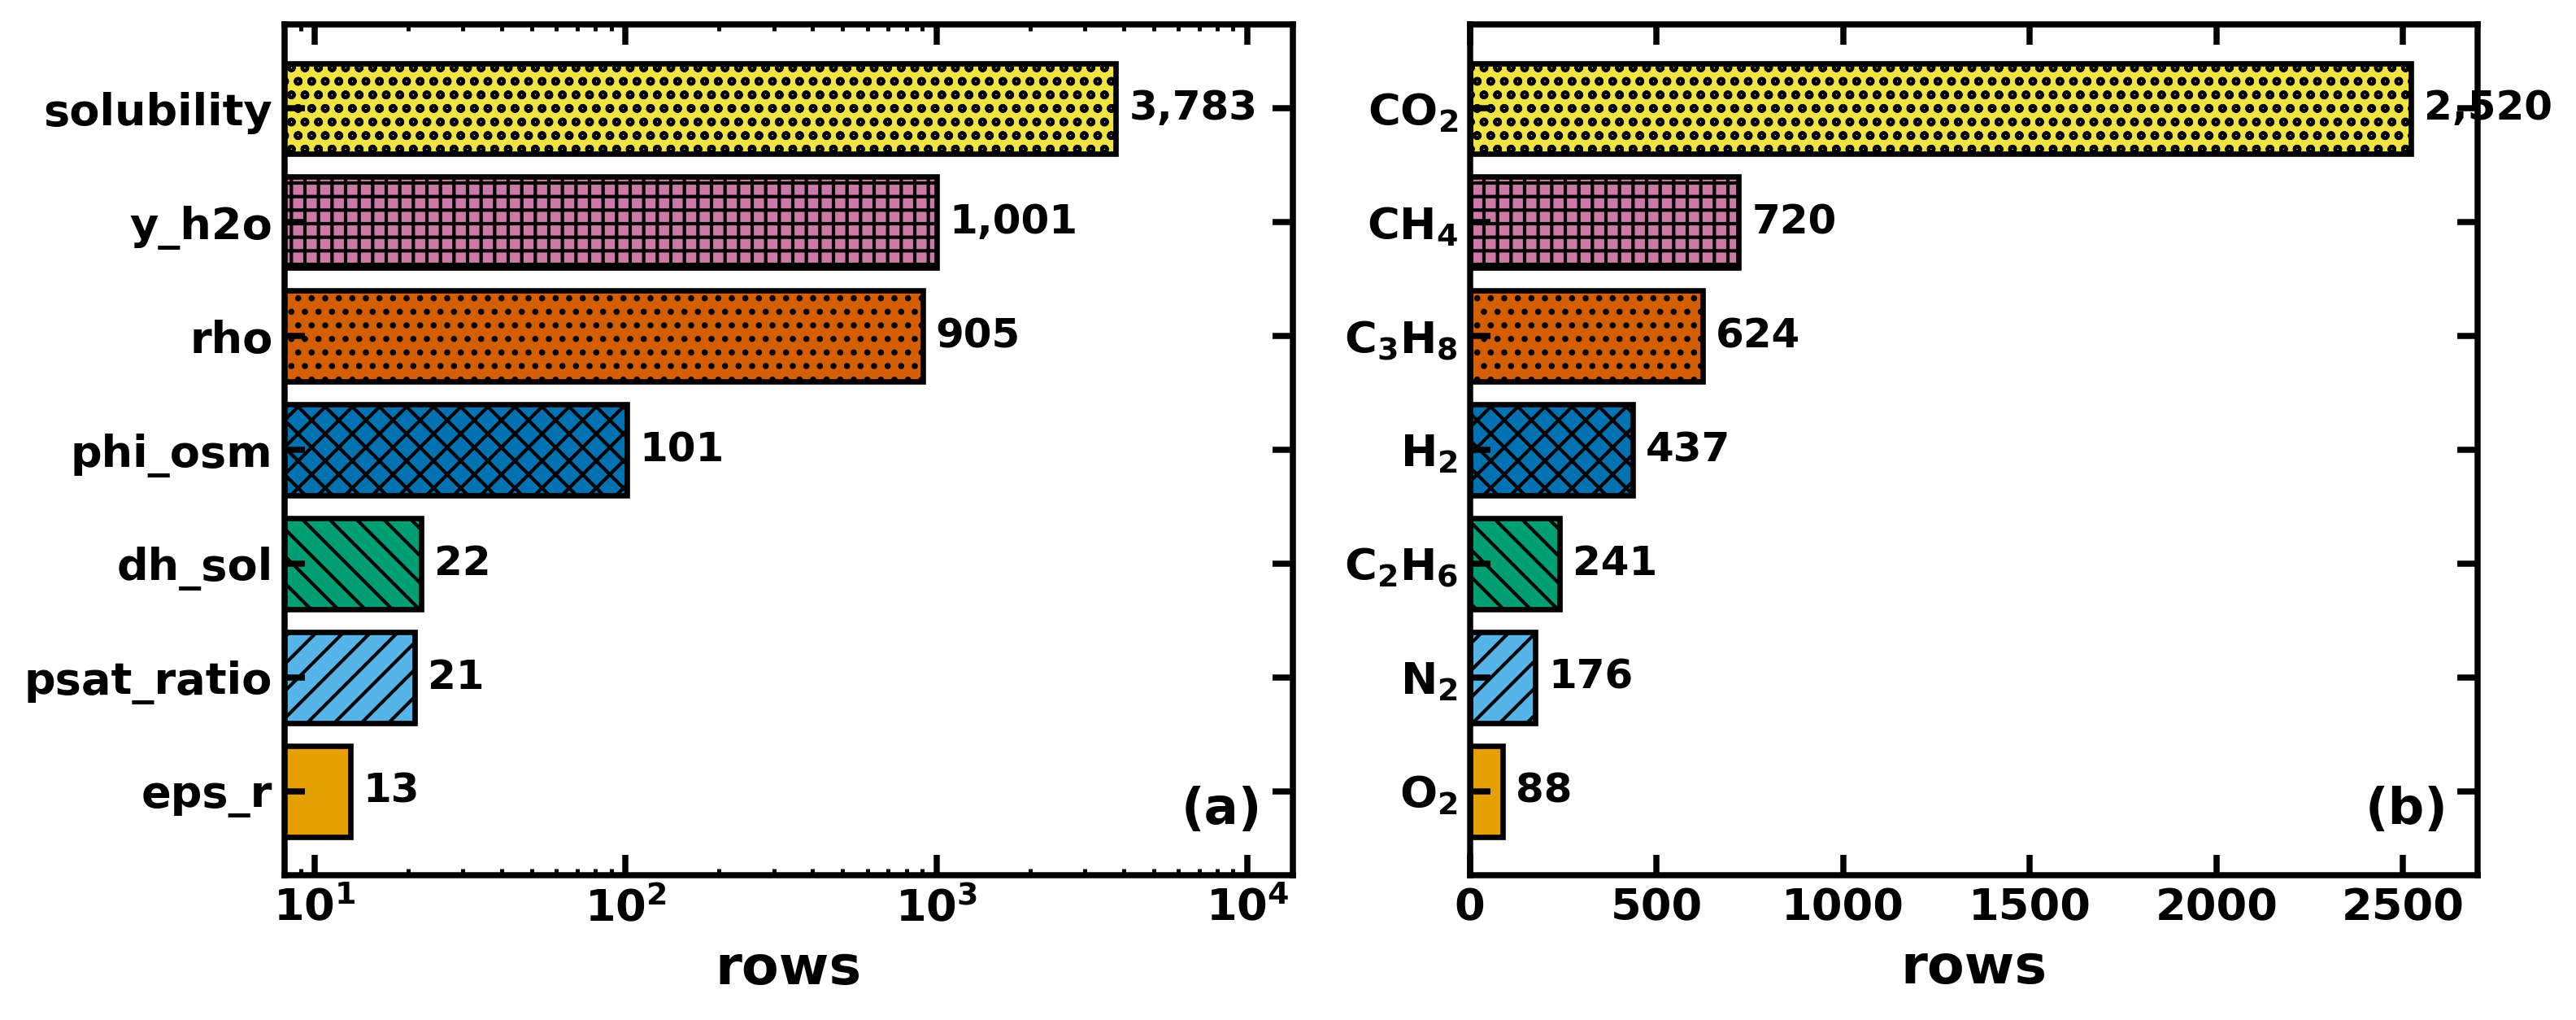

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4))

inv = gbb.inventory(everything).sort_values("rows")
ax = axes[0]
for i, (name, row) in enumerate(inv.iterrows()):
    ax.barh(name, row["rows"], color=WONG[ORDER[i % len(ORDER)]],
            edgecolor="black", linewidth=1.6, hatch=HATCHES[i % len(HATCHES)])
    ax.text(row["rows"] * 1.10, i, f"{int(row['rows']):,}", va="center",
            fontweight="bold", fontsize=12)
ax.set_xscale("log")
ax.set_xlim(8, 14000)
label(ax, "rows", "")
ax.text(0.97, 0.06, "(a)", transform=ax.transAxes, fontweight="bold",
        fontsize=15, ha="right")

ax = axes[1]
gi = gbb.inventory(everything[everything["gas"] != ""],
                   by="gas").sort_values("rows")
for i, (name, row) in enumerate(gi.iterrows()):
    ax.barh(GAS_LABEL[name], row["rows"], color=WONG[ORDER[i % len(ORDER)]],
            edgecolor="black", linewidth=1.6, hatch=HATCHES[i % len(HATCHES)])
    ax.text(row["rows"] + 35, i, f"{int(row['rows']):,}", va="center",
            fontweight="bold", fontsize=12)
ax.set_xlim(0, 2700)
label(ax, "rows", "")
ax.text(0.97, 0.06, "(b)", transform=ax.transAxes, fontweight="bold",
        fontsize=15, ha="right")

fig.tight_layout()
plt.show()

### Figure 3 -- how the quality codes fall

Every row carries an **R / T / U** code, assigned by the consistency
methodology of Yang et al. (*Ind. Eng. Chem. Res.* **2022**, 61, 15576) and
justified row block by row block in `data/QUALITY.md`:

- **R**, recommended -- independently corroborated by another source at
  matched conditions;
- **T**, tentative -- plausible, but the only source at those conditions;
- **U**, uncertain -- contradicted by independent work, flagged by the authors
  themselves, or unverifiable.

`T` dominates, and that is the honest state of this literature rather than a
gap in the curation: corroboration requires two laboratories to have visited
the same state, which for most of this (T, P, composition) space nobody has.
The families where `R` is common are the ones with a dense overlap
(`phi_osm`, `psat_ratio`); `rho` is entirely `T` because its 42 sources cover
disjoint conditions.

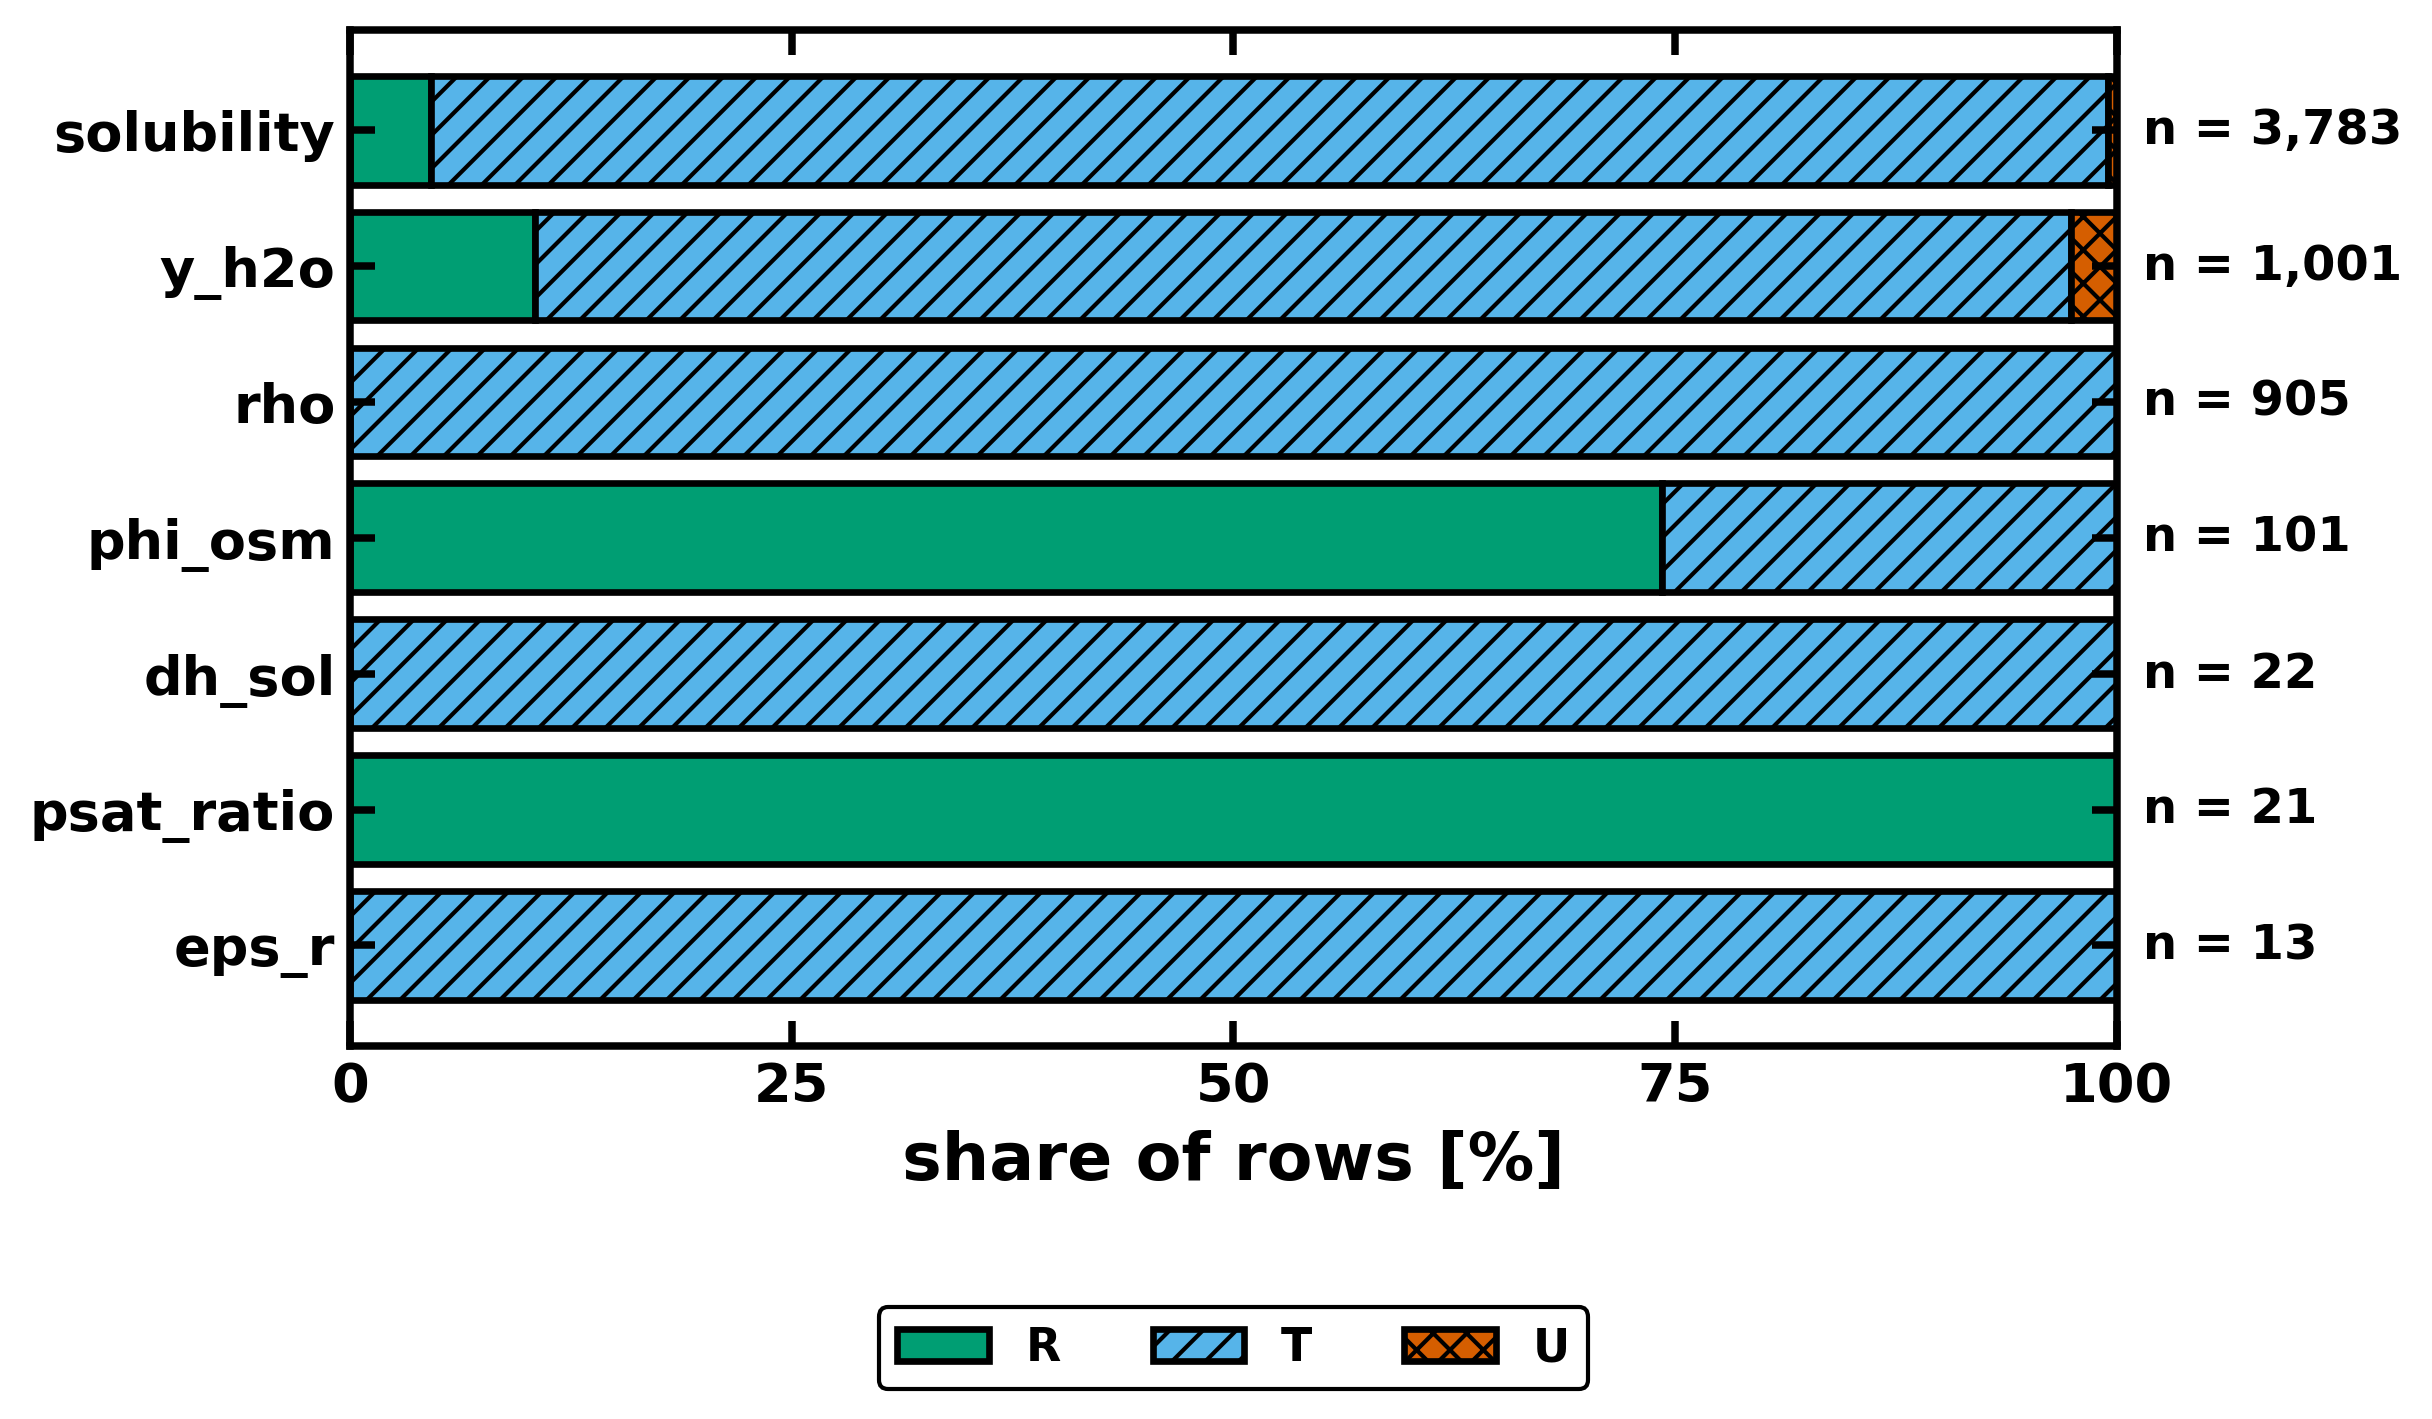

In [11]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))

inv = gbb.inventory(everything).sort_values("rows")
frac = inv[["R", "T", "U"]].div(inv["rows"], axis=0) * 100

left = np.zeros(len(inv))
for j, code_ in enumerate(["R", "T", "U"]):
    v = frac[code_].to_numpy(float)
    ax.barh(inv.index, v, left=left, color=WONG[[3, 2, 6][j]],
            edgecolor="black", linewidth=1.6, hatch=["", "///", "xxx"][j],
            label=code_)
    left += v
for i, (name, row) in enumerate(inv.iterrows()):
    ax.text(101.5, i, f"n = {int(row['rows']):,}", va="center",
            fontweight="bold", fontsize=11.5)

ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
label(ax, "share of rows [%]", "")
ax.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.36))
plt.show()

### Figure 4 -- which brines are represented

Ion-set labels, not salt names, because a brine containing Na, Cl, K and Ca
cannot be resolved into salts without an assumption the measurement does not
carry. The five single-salt systems are labelled with the salt they
unambiguously correspond to; the mixed brines keep their ion sets.

Salt-free binaries are the largest single block -- they are what the brine
rows are measured against.

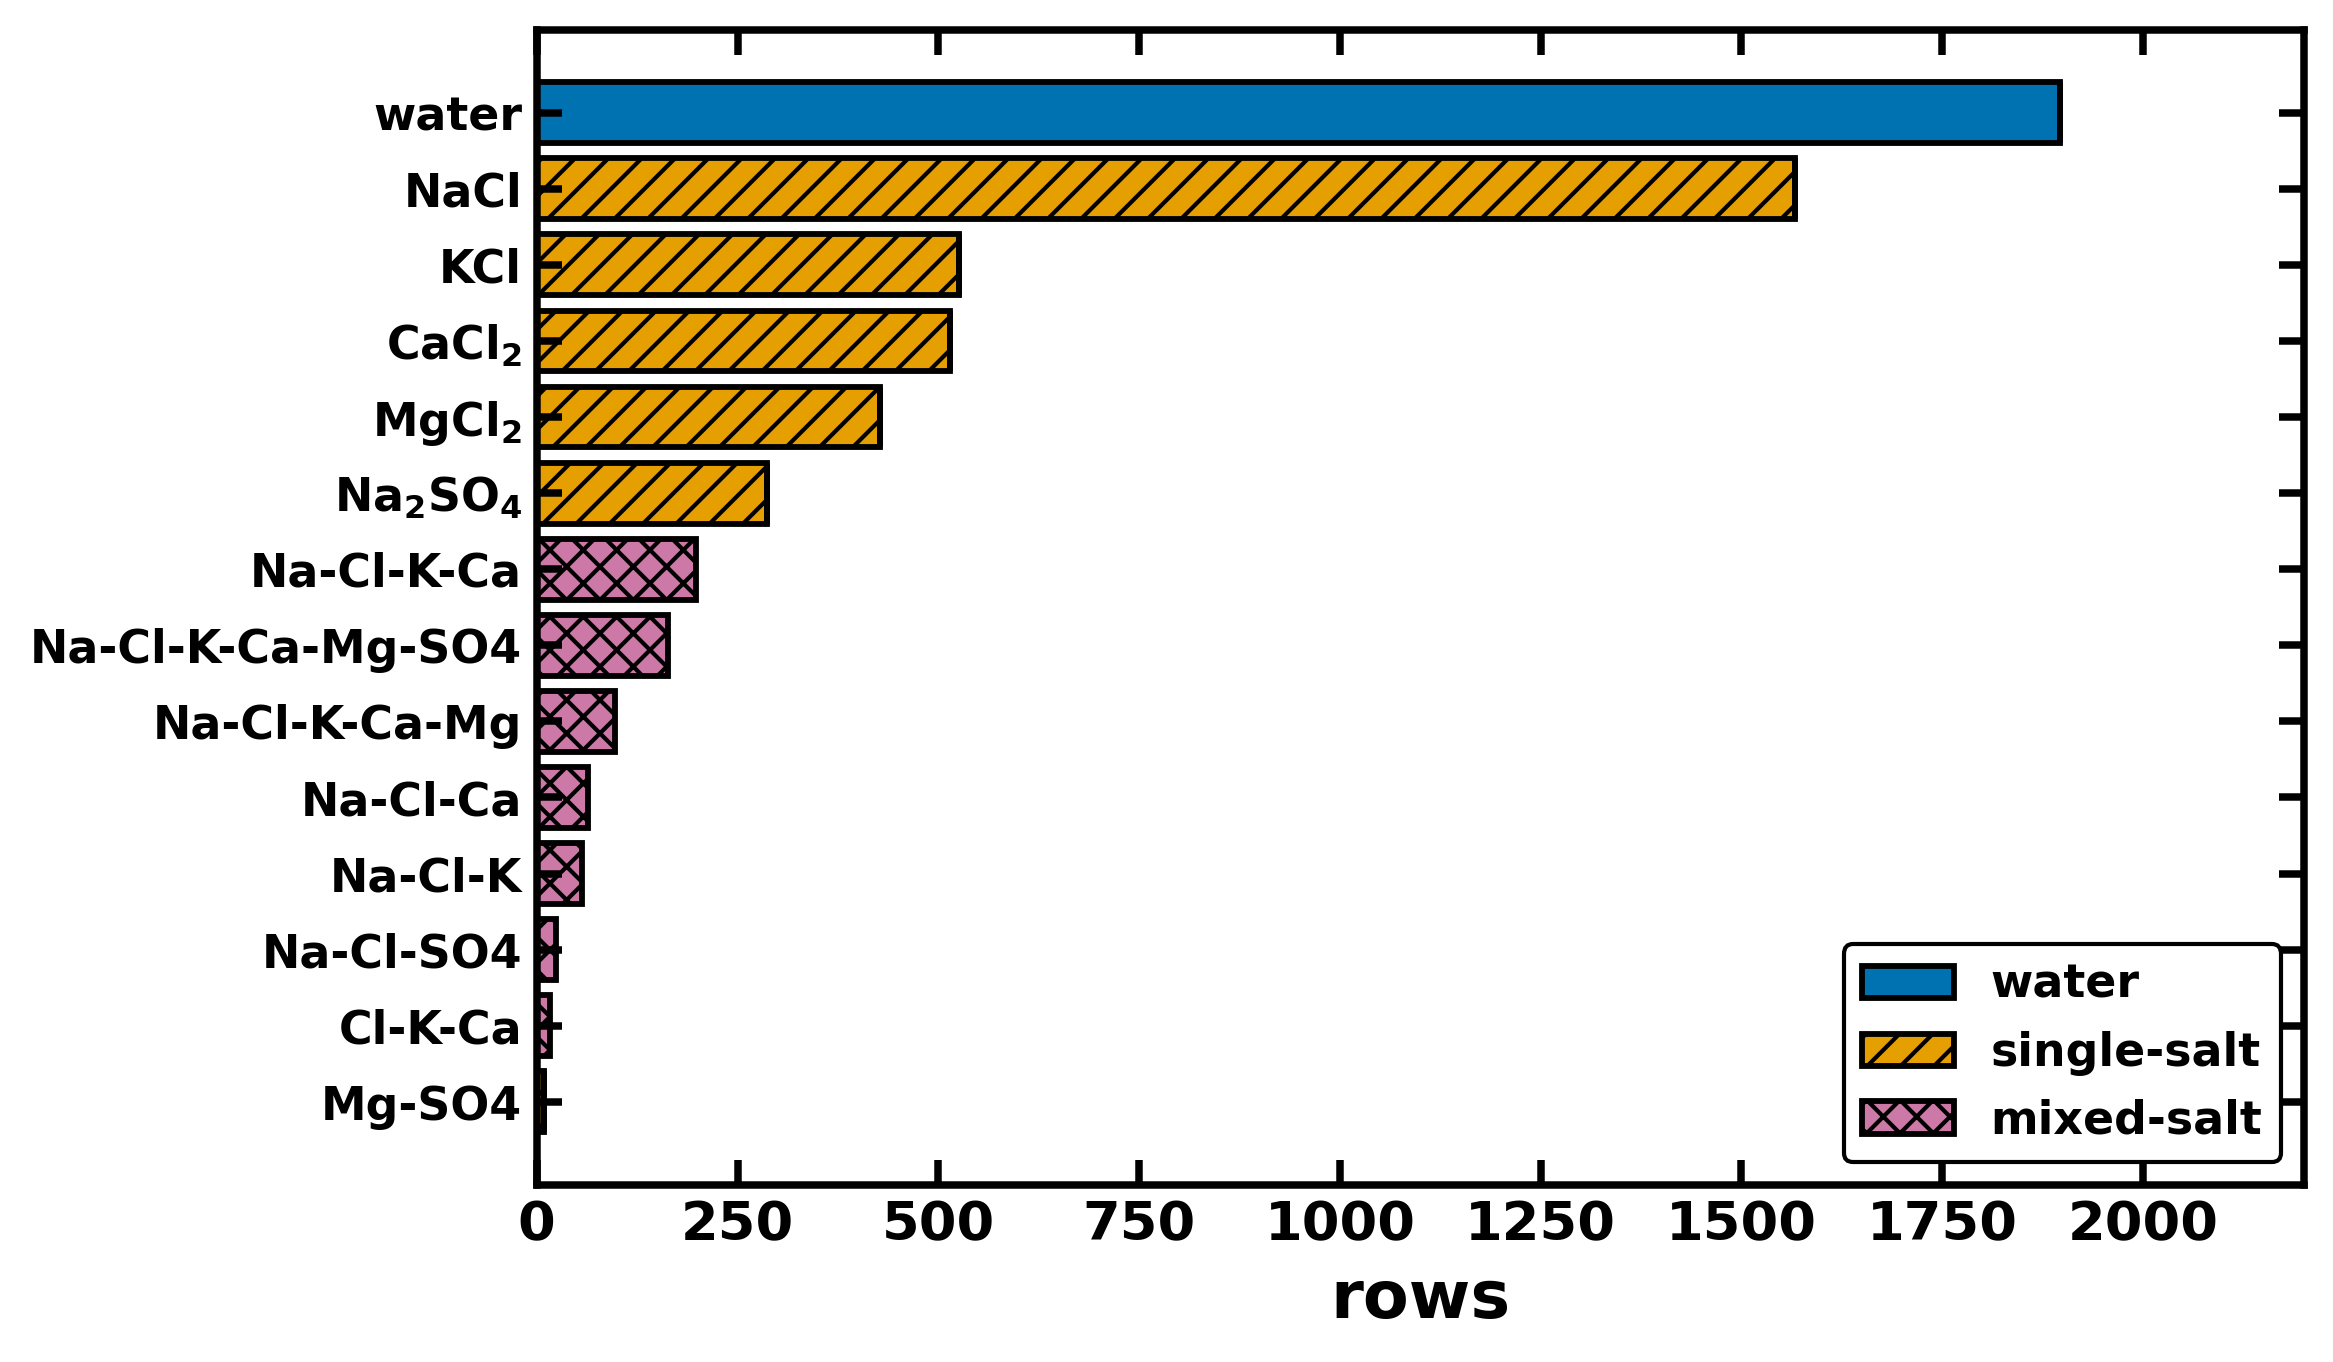

In [12]:
fig, ax = plt.subplots(figsize=(7.6, 5.0))

tab = pd.crosstab(gbb.salt_system(everything),
                  gbb.salt_system_kind(everything))
tab["total"] = tab.sum(axis=1)
tab = tab.sort_values("total")
kinds = [c for c in ["water", "single-salt", "mixed-salt"] if c in tab.columns]

left = np.zeros(len(tab))
for j, k in enumerate(kinds):
    v = tab[k].to_numpy(float)
    ax.barh([SALT_LABEL.get(i, i) for i in tab.index], v, left=left,
            color=WONG[[5, 1, 7][j]], edgecolor="black", linewidth=1.4,
            hatch=["", "///", "xxx"][j], label=k)
    left += v

ax.set_xlim(0, 2200)
label(ax, "rows", "")
ax.legend(loc="lower right")
ax.tick_params(axis="y", labelsize=11)
plt.show()

---

## 3. Filtering

`gbb.select()` takes one keyword per axis you might actually want: gas,
property family, salt system, ion content, T / P / ionic-strength window,
quality code, tag, source. Everything is optional and everything is ANDed.
`gbb.load()` forwards the same keywords, so the common case is a single call.

A typo raises rather than returning an empty frame, which in a benchmark is
the difference between a bug you find in a second and one you find after the
paper is out.

In [13]:
# One call, several axes.
hot_brine = gbb.load("solubility", gas="co2",
                     property="solubility_molality",
                     T=(373, 425), ionic_strength=(2, None))
print(f"CO2 solubility, 373-425 K, I >= 2 mol/kg : {len(hot_brine):,} rows "
      f"from {hot_brine['source'].nunique()} sources")

# Compose instead, if you prefer.
recommended = gbb.select(df, quality="R", salt_system="single-salt")
print(f"single-salt rows coded R                 : {len(recommended):,} rows")

# By ion content: everything containing sulfate, whatever else is there.
sulfate = gbb.select(df, ions="SO4")
print(f"rows containing sulfate                  : {len(sulfate):,} rows")

# Exact ion set: NaCl brines only, no other ion present.
nacl_only = gbb.select(df, ions_exactly=["Na", "Cl"])
print(f"NaCl-only brines                         : {len(nacl_only):,} rows")

CO2 solubility, 373-425 K, I >= 2 mol/kg : 385 rows from 22 sources
single-salt rows coded R                 : 245 rows
rows containing sulfate                  : 484 rows
NaCl-only brines                         : 1,567 rows


In [14]:
# A typo is an error, not an empty frame.
try:
    gbb.select(df, gas="CO_2")
except ValueError as exc:
    print("ValueError:", exc)

try:
    gbb.select(df, quality="A")
except ValueError as exc:
    print("ValueError:", exc)

ValueError: unknown gas 'CO_2'. Valid values: co2, ch4, h2, n2, o2, c2h6, c3h8
ValueError: unknown quality code 'A'. Valid values: R, T, U


## 4. Derived quantities

Three things the CSVs do not store, because they follow from what they do
store:

- **ionic strength** $I = \tfrac12 \sum_i m_i z_i^2$ and **total ion
  molality** $\sum_i m_i$ -- attached as columns by `load()`, or available as
  functions;
- **charge imbalance** $\sum_i m_i z_i$, which is zero for a stoichiometric
  brine and, across this database, never larger than about $2\times10^{-3}$
  eq/kg -- a residue of the rounded molalities the sources printed, and
  something any speciation code has to be told what to do about;
- the **mole-fraction siblings** of a solubility.

On that last point: `data/solubility.csv` stores a solubility twice when the
source reported both conventions -- once as `solubility_molality`
[mol gas / kg water] and once as `xc_saltfree`, the salt-free-basis gas mole
fraction -- as two rows at the same state. `gbb.solubility_pairs()` pivots
them back together, recomputes the salt-free fraction from the molality (so
the gaps are filled where the source gave only one convention), and adds the
**salt-inclusive** fraction, in which the dissolved ions count as species.
That last one is derived, not measured: nobody reports it, but many models
expect it, and doing the conversion here makes the convention explicit.

In [15]:
sol = gbb.solubility_pairs(gbb.load("solubility"))
print(f"{len(sol):,} measured solubility points")

cols = ["source", "gas", "T_K", "P_bar", "ionic_strength",
        "solubility_molality", "xc_saltfree", "xc_saltfree_derived",
        "xc_saltinclusive"]
sol[sol["gas"] == "co2"][cols].head(6)

2,089 measured solubility points


,source,gas,T_K,P_bar,ionic_strength,solubility_molality,xc_saltfree,xc_saltfree_derived,xc_saltinclusive
0,TEYMOURI(2017),co2,323.0,122.76,1.9,0.753915,0.0134,0.0134,0.012552
1,TEYMOURI(2017),co2,323.0,259.31,1.9,0.919780,0.0163,0.0163,0.015272
2,TEYMOURI(2017),co2,323.0,537.93,1.9,1.121268,0.0198,0.0198,0.018555
3,TEYMOURI(2017),co2,323.0,27.86,3.0,0.306985,0.0055,0.0055,0.004966
4,TEYMOURI(2017),co2,323.0,131.03,3.0,0.628736,0.0112,0.0112,0.010119
5,TEYMOURI(2017),co2,323.0,356.55,3.0,0.816715,0.0145,0.0145,0.013104


In [16]:
# The stored and recomputed salt-free fractions agree to the tolerance
# tools/validate.py enforces; the salt-inclusive sibling is always smaller
# in a brine, because the ions are extra species in the denominator.
both = sol.dropna(subset=["xc_saltfree"])
agree = (both["xc_saltfree"] - both["xc_saltfree_derived"]).abs()
tol = 1e-9 + 1e-6 * both["xc_saltfree"].abs()
print("stored vs recomputed salt-free fraction, all within tolerance:",
      bool((agree <= tol).all()))

brine_pts = sol[sol["total_molality"] > 0]
print("salt-inclusive < salt-free in every brine row:",
      bool((brine_pts["xc_saltinclusive"]
            < brine_pts["xc_saltfree_derived"]).all()))

print("max |charge imbalance| over the database: "
      f"{gbb.charge_imbalance(everything).abs().max():.1e} eq/kg")

stored vs recomputed salt-free fraction, all within tolerance: True
salt-inclusive < salt-free in every brine row: True
max |charge imbalance| over the database: 2.0e-03 eq/kg


---

## 5. The physics

### Figure 5 -- CO$_2$ solubility isotherms in 1 mol/kg NaCl

Solubility rises steeply with pressure and then flattens as the gas phase
densifies. The 323 K isotherm sits above the hotter ones at low pressure and
is overtaken above roughly 200 bar: the familiar crossing of the
carbon-dioxide-brine isotherms, and the reason a model fitted at one
temperature does not automatically work at another.

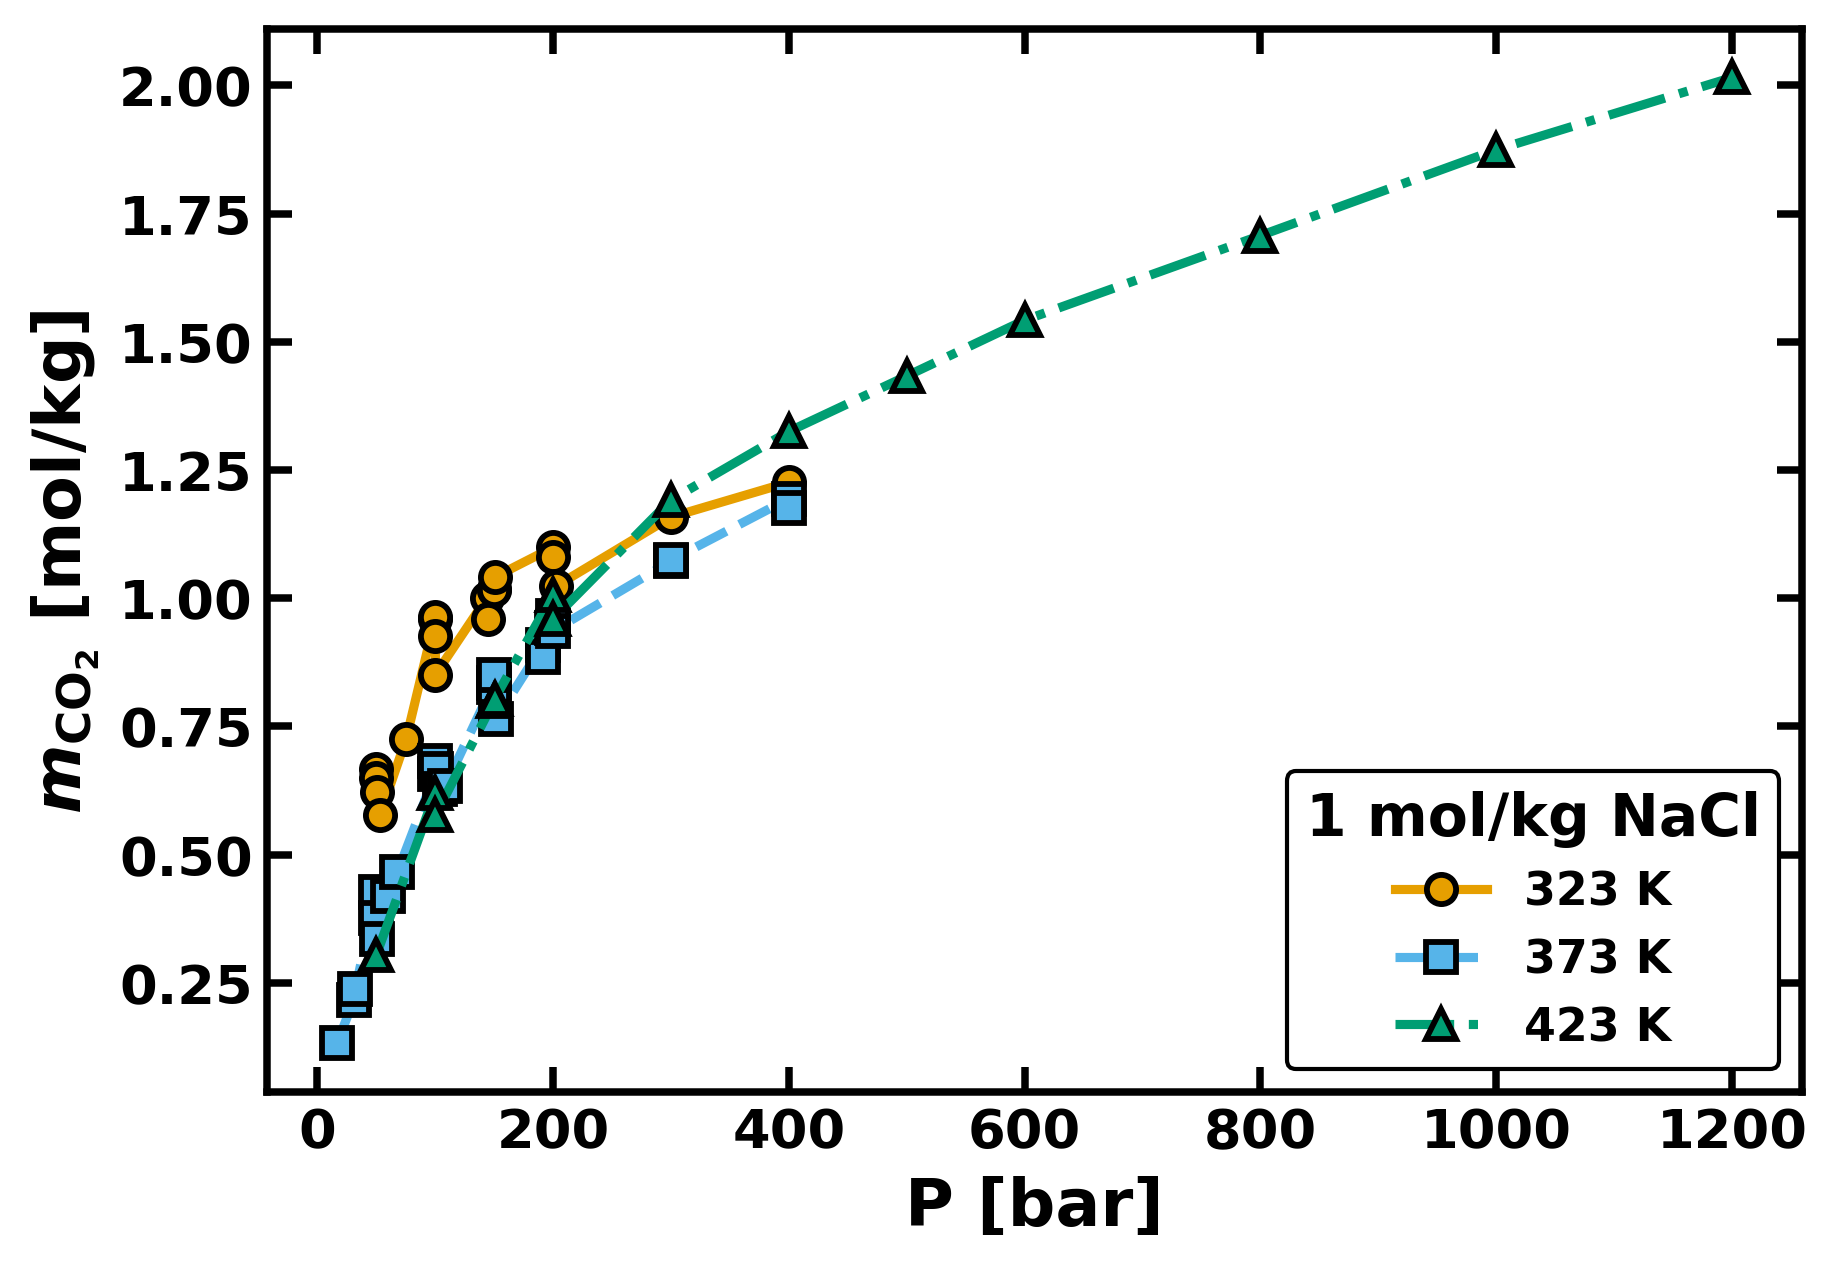

In [17]:
fig, ax = plt.subplots()

sub = sol[(sol["gas"] == "co2") & (sol["salt_system"] == "Na-Cl")
          & (sol["m_Na"].between(0.9, 1.15))]
for i, T in enumerate([323, 373, 423]):
    s = sub[sub["T_K"].between(T - 1.5, T + 1.5)].sort_values("P_bar")
    ax.plot(s["P_bar"], s["solubility_molality"], **series_style(i),
            markeredgecolor="black", label=f"{T} K")

label(ax, "P [bar]", r"$m_{\mathrm{CO_2}}$ [mol/kg]")
ax.legend(loc="lower right", title="1 mol/kg NaCl",
          title_fontproperties={"weight": "bold"})
plt.show()

### Figure 6 -- salting out, at 323 K

The same gas, the same temperature, four pressures: adding NaCl drives
CO$_2$ out of solution, roughly halving its solubility between fresh water
and a 6 mol/kg brine. The curves are close to parallel on a linear axis,
which is what makes a Setschenow-type description work as well as it does --
and the residual departure from parallel is what a model has to get right.

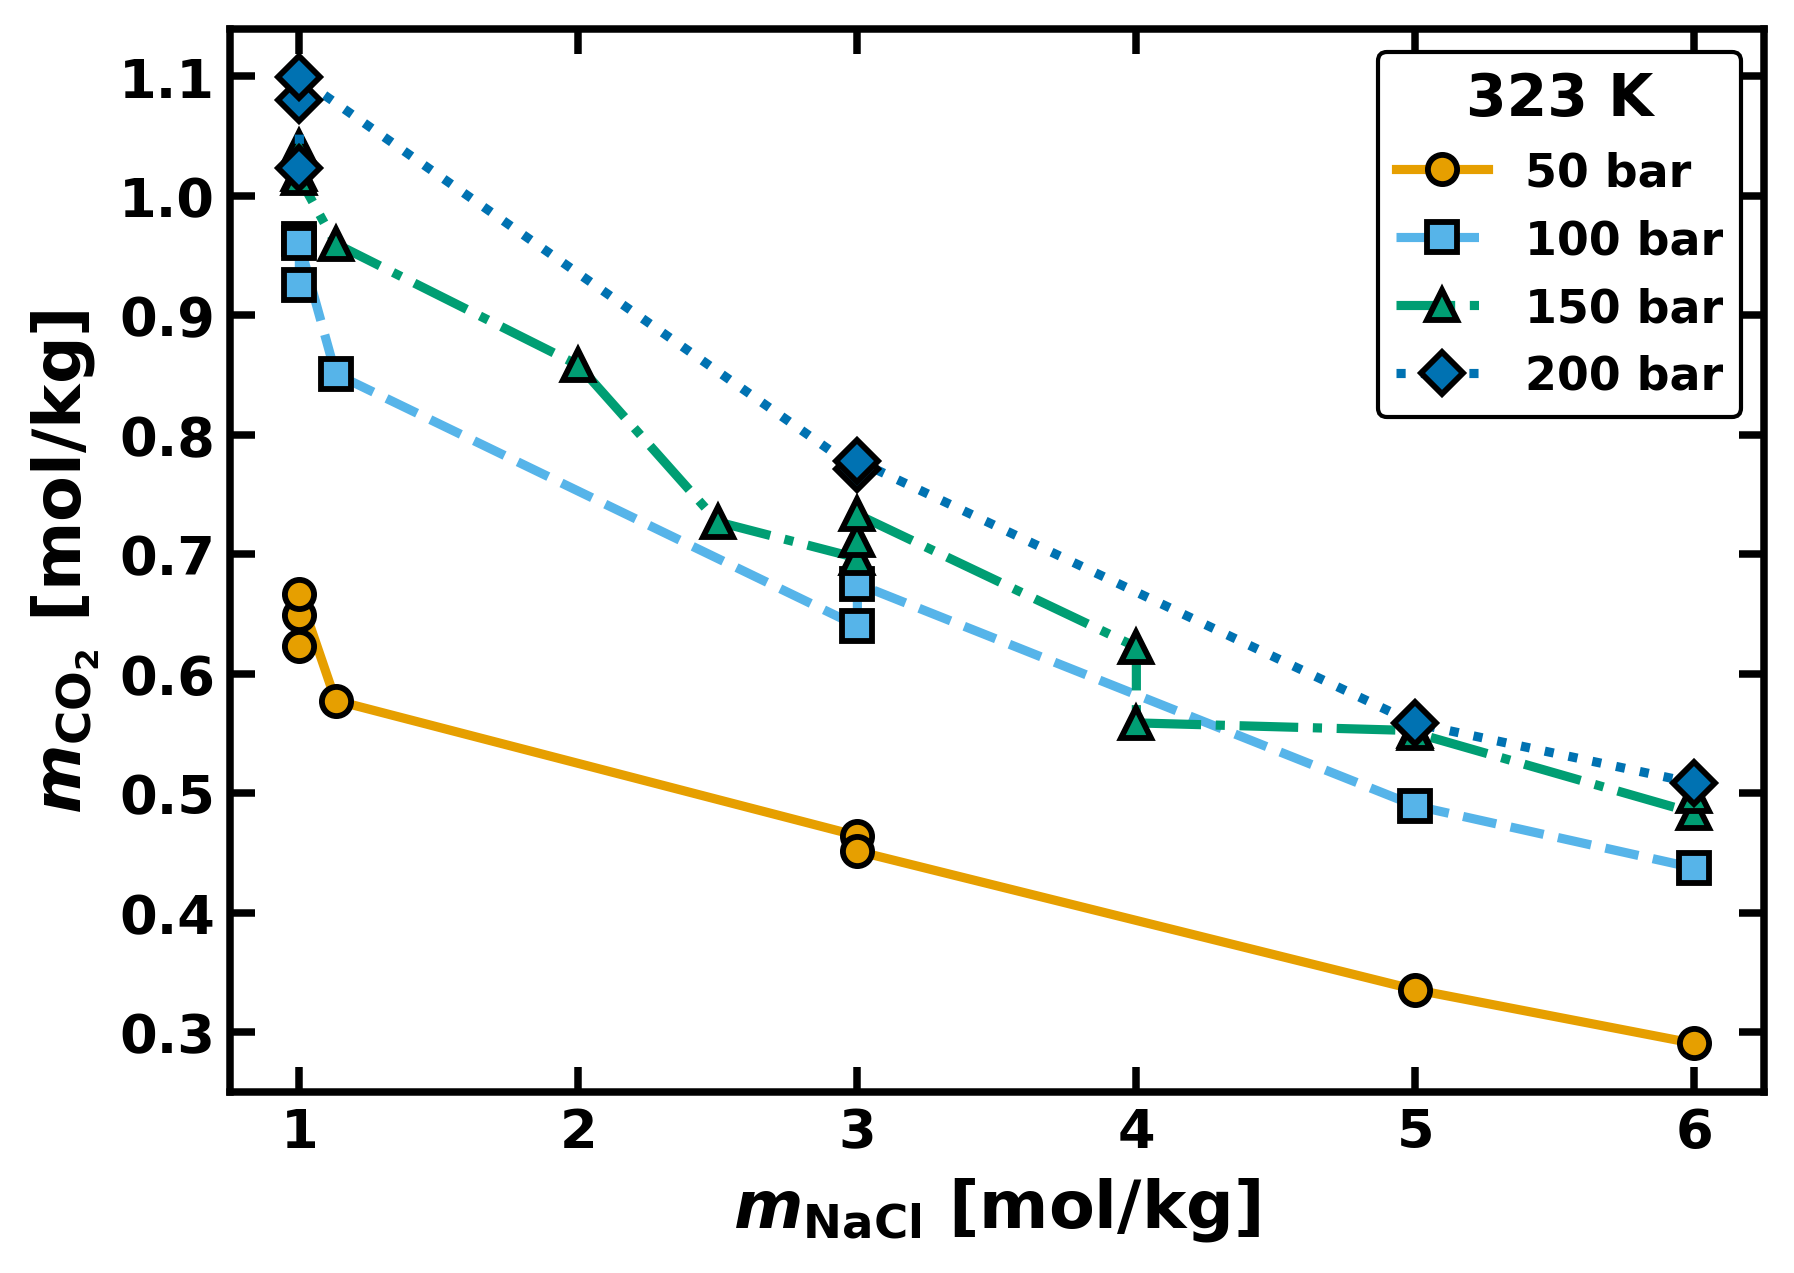

In [18]:
fig, ax = plt.subplots()

sub = sol[(sol["gas"] == "co2") & (sol["salt_system"] == "Na-Cl")
          & (sol["T_K"].between(322, 324))]
for i, P in enumerate([50, 100, 150, 200]):
    s = sub[sub["P_bar"].between(P - 6, P + 6)].sort_values("m_Na")
    if len(s) < 3:
        continue
    ax.plot(s["m_Na"], s["solubility_molality"], **series_style(i),
            markeredgecolor="black", label=f"{P} bar")

label(ax, r"$m_{\mathrm{NaCl}}$ [mol/kg]", r"$m_{\mathrm{CO_2}}$ [mol/kg]")
ax.legend(loc="upper right", title="323 K",
          title_fontproperties={"weight": "bold"})
plt.show()

### Figure 7 -- salting out depends on which ions, not just how many

One temperature, one pressure, five single-salt systems, plotted against
ionic strength so that the charge of the ions is already accounted for. If
salting out depended on ionic strength alone the curves would collapse onto
one line. They do not: Na$_2$SO$_4$ and NaCl sit below KCl at the same
ionic strength, and the divalent-chloride brines reach ionic strengths no
1:1 salt can.

This is exactly the behaviour a mixed-salt model has to reproduce, and the
reason the database carries ion molalities rather than a single salinity.

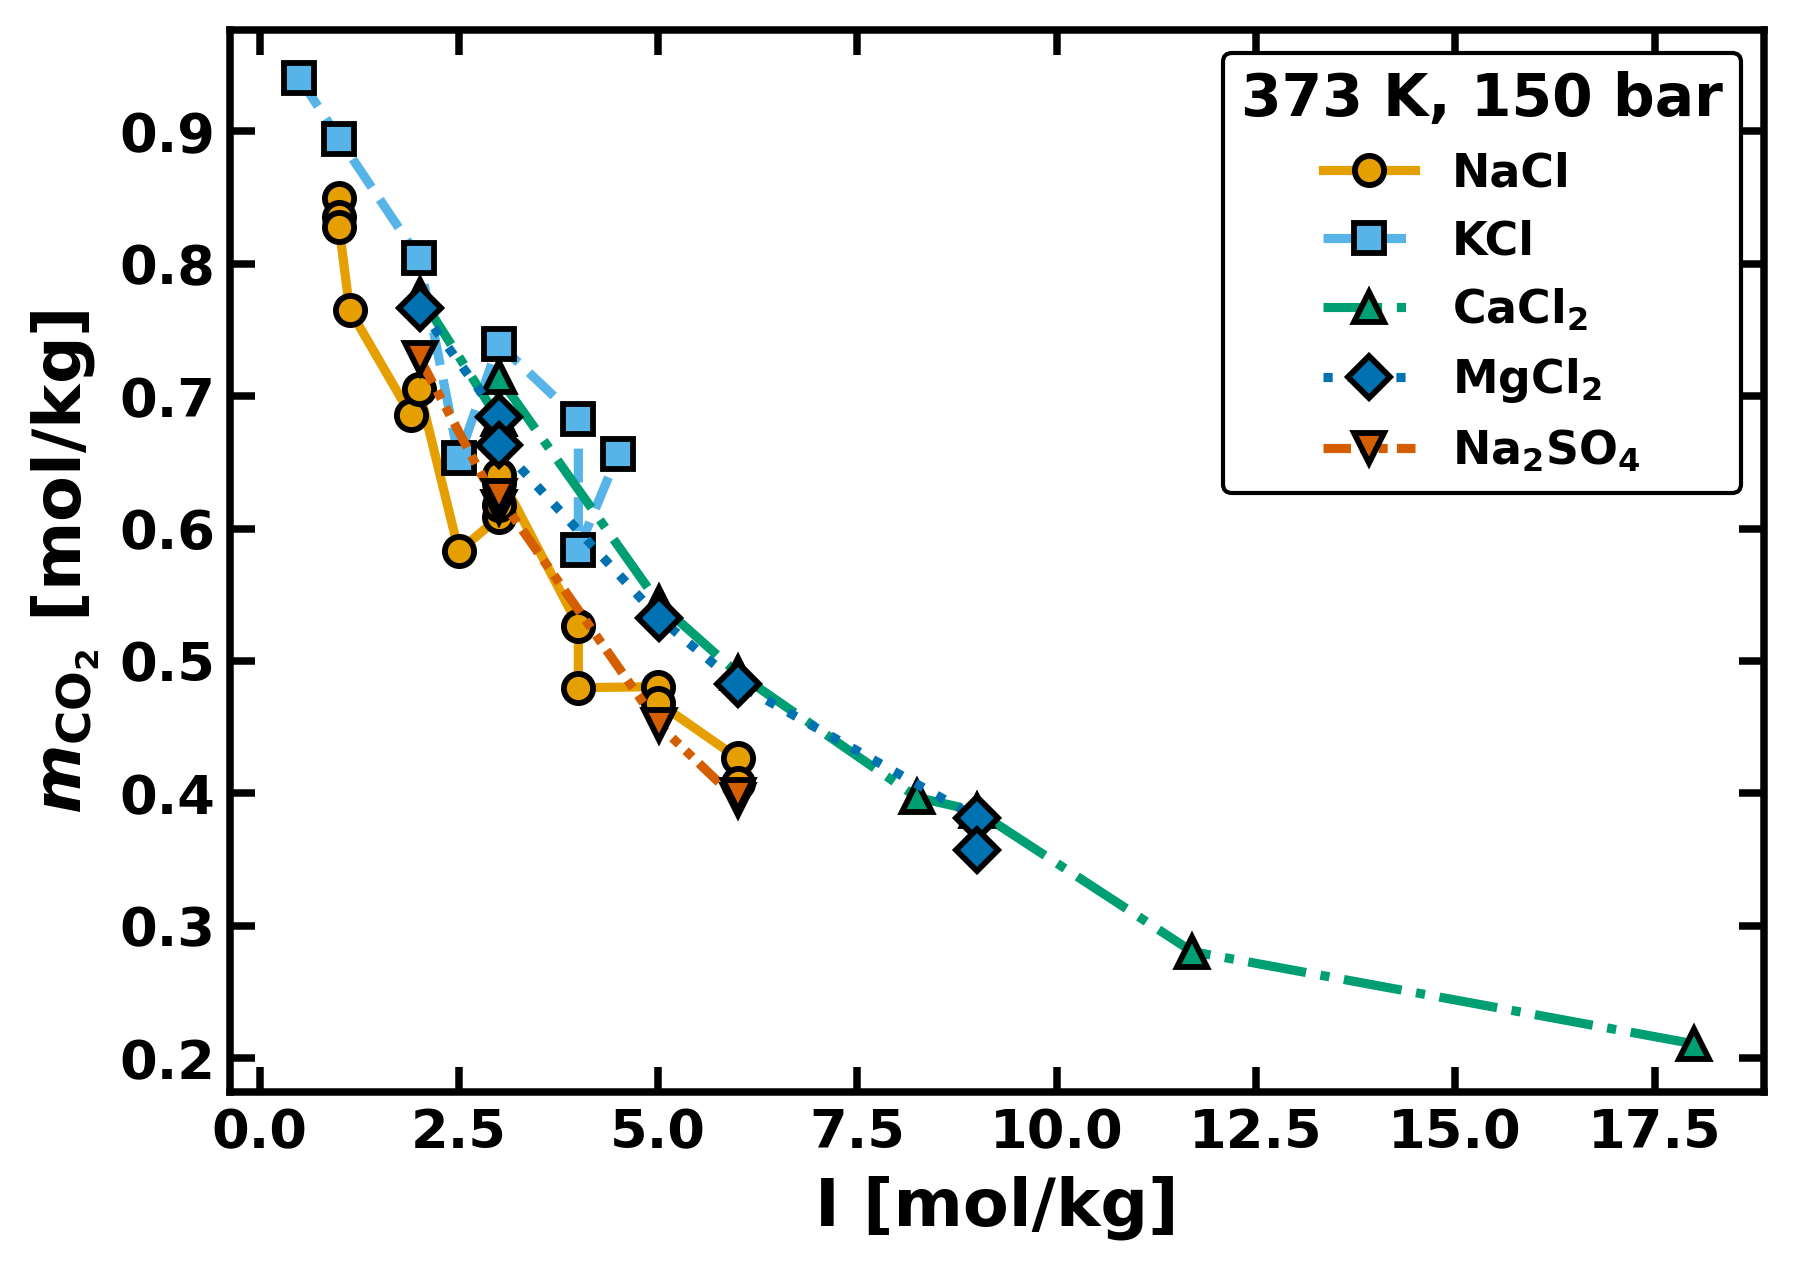

In [19]:
fig, ax = plt.subplots()

sub = sol[(sol["gas"] == "co2") & (sol["T_K"].between(372, 374))
          & (sol["P_bar"].between(145, 155))]
for i, sysname in enumerate(["Na-Cl", "Cl-K", "Cl-Ca", "Cl-Mg", "Na-SO4"]):
    s = sub[sub["salt_system"] == sysname].sort_values("ionic_strength")
    ax.plot(s["ionic_strength"], s["solubility_molality"], **series_style(i),
            markeredgecolor="black", label=SALT_LABEL[sysname])

label(ax, "I [mol/kg]", r"$m_{\mathrm{CO_2}}$ [mol/kg]")
ax.legend(loc="upper right", title="373 K, 150 bar",
          title_fontproperties={"weight": "bold"})
plt.show()

### Figure 8 -- water content of the CO$_2$-rich phase

The other half of the equilibrium, and the one that matters for pipeline and
wellbore integrity: how much water the gas phase carries. Each isotherm falls
as $1/P$ while the gas is nearly ideal, reaches a minimum near the point where
the CO$_2$ condenses or turns dense, and then rises again as the dense phase
starts to dissolve water like a solvent. Several sources contribute to each
isotherm and each is drawn as its own segment, so the lines break where one
laboratory's range ends and another begins.

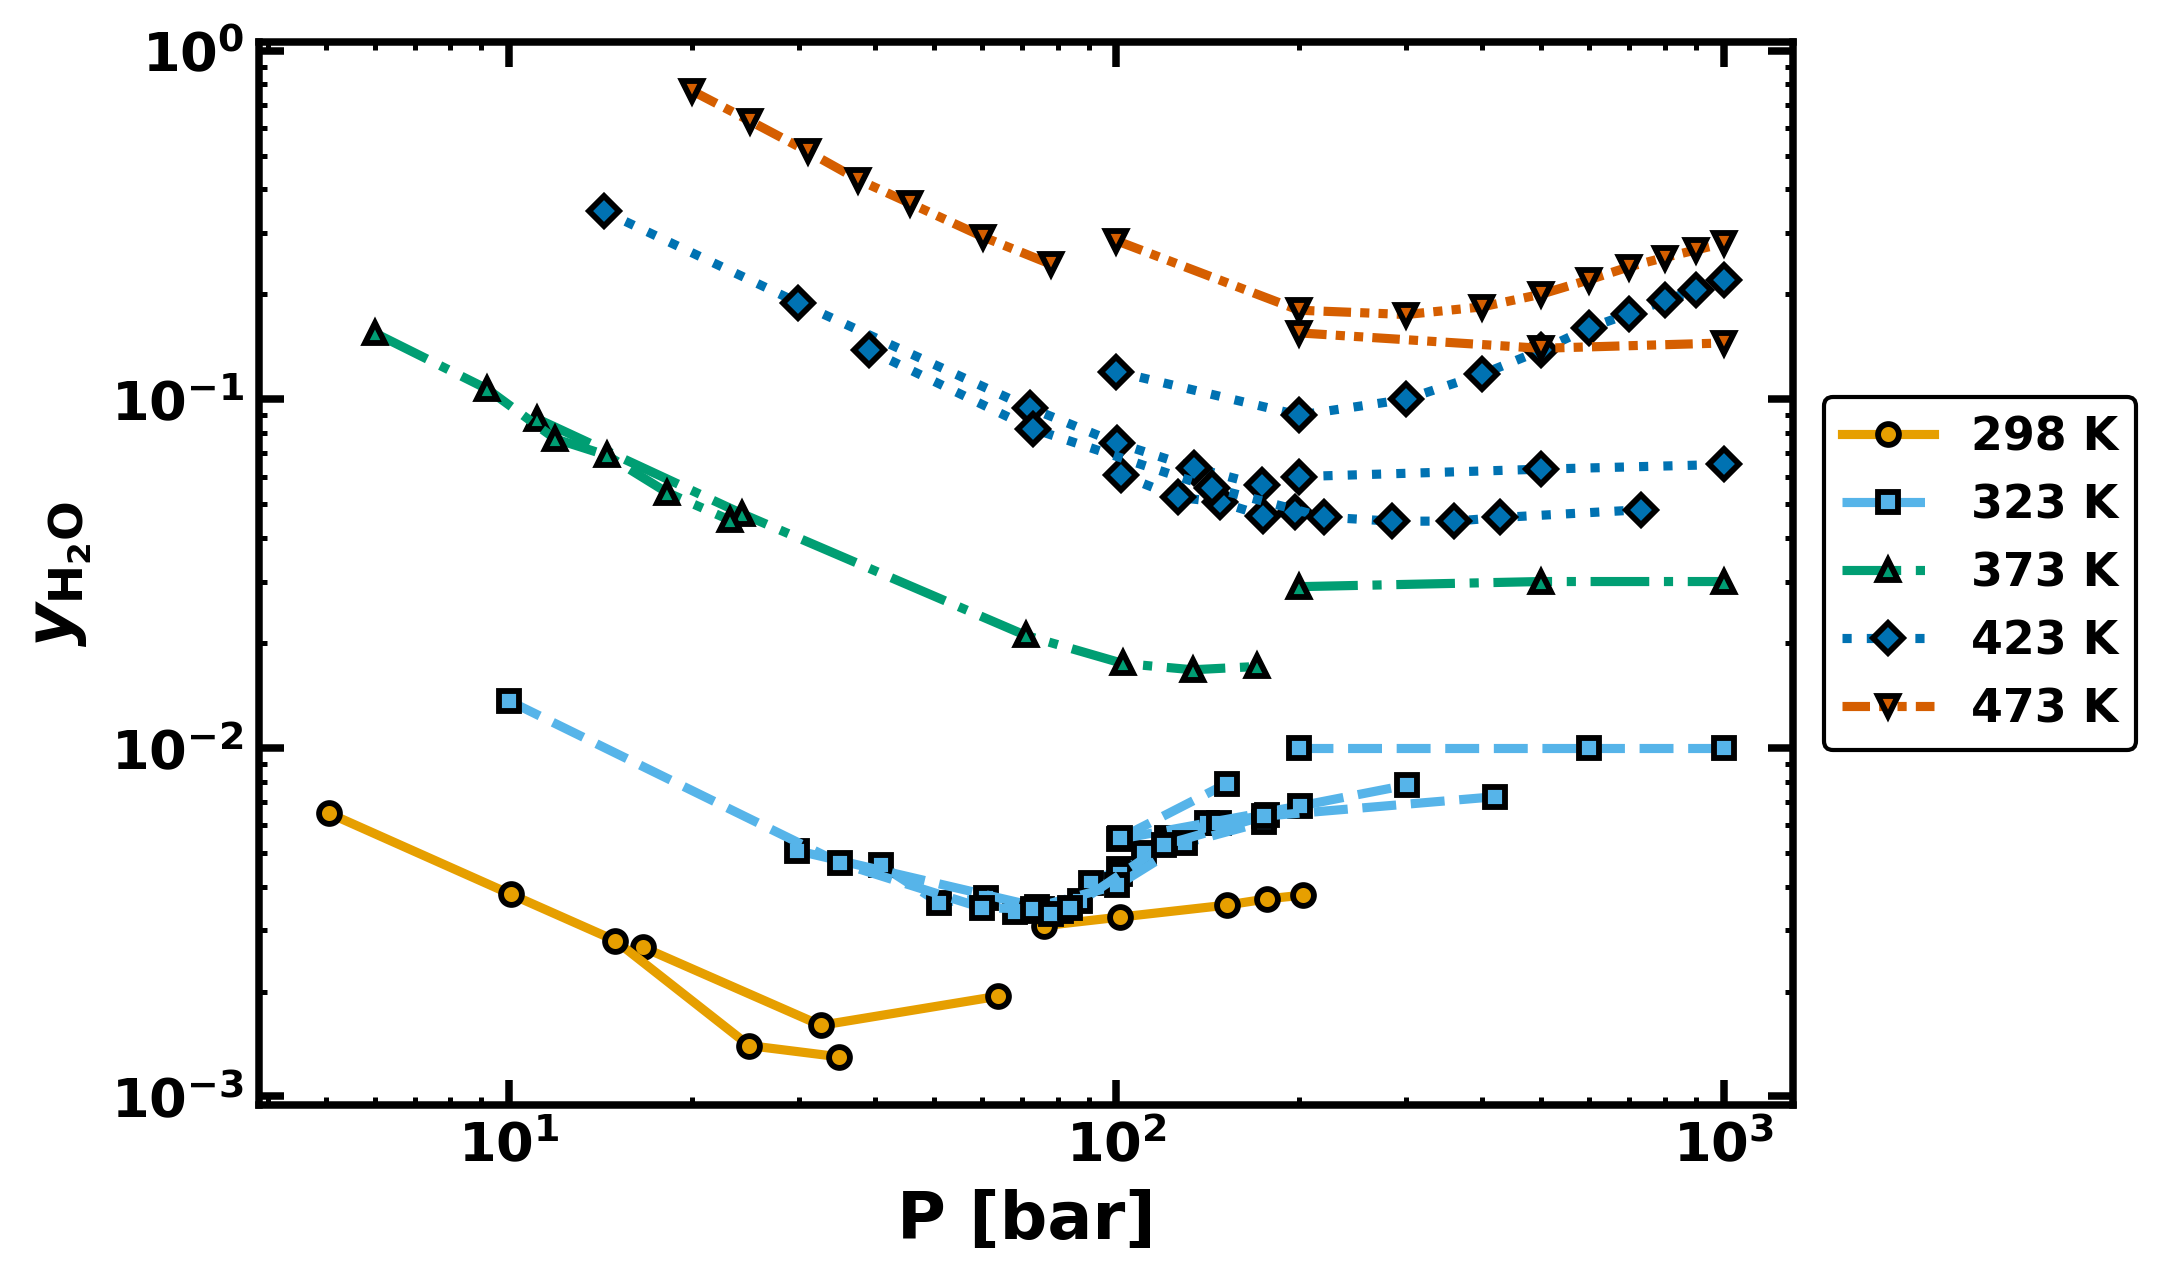

In [20]:
fig, ax = plt.subplots()

y = gbb.select(df, property="y_h2o", gas="co2", salt_free=True)
for i, T in enumerate([298, 323, 373, 423, 473]):
    s = y[y["T_K"].between(T - 1.5, T + 1.5) & (y["P_bar"] <= 1000)]
    first = True
    for _, g in s.groupby("source"):
        g = g.sort_values("P_bar")
        if len(g) < 2:
            continue
        ax.plot(g["P_bar"], g["value"], **series_style(i),
                markeredgecolor="black", markersize=5,
                label=f"{T} K" if first else None)
        first = False

ax.set_xscale("log")
ax.set_yscale("log")
label(ax, "P [bar]", r"$y_{\mathrm{H_2O}}$")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.show()

---

## 6. Different laboratories at the same conditions

The next two figures show what a benchmark curator spends most of their time
looking at: several independent measurements of the same quantity at the same
state. Each source is drawn as its own curve, and the shaded envelope is
simply the region those curves span, drawn wherever at least two sources
overlap in pressure.

The envelope is a picture, not a measurement. **This notebook does not
quantify it**: no spread statistic, no comparison with the uncertainties the
original authors stated, no claim about what the width does or does not imply
for telling models apart. That analysis belongs to the benchmark paper in
preparation. What is worth taking from these two figures is only the
qualitative shape: that the envelope is there, and that it is not uniform in
pressure.

In [21]:
def envelope(sub, xcol, ycol, group="source", n=80, min_sources=2, logx=False):
    """Region spanned by the per-source curves, on a common x grid.

    A drawing aid for fill_between: it returns the outline of the reported
    values, and deliberately computes nothing about how wide that outline is.
    """
    x_all = sub[xcol].to_numpy(float)
    lo_x, hi_x = np.nanmin(x_all), np.nanmax(x_all)
    grid = np.geomspace(lo_x, hi_x, n) if logx else np.linspace(lo_x, hi_x, n)

    curves = []
    for _, g in sub.groupby(group):
        g = g.dropna(subset=[xcol, ycol]).sort_values(xcol)
        if len(g) < 2:
            continue
        x = g[xcol].to_numpy(float)
        yv = g[ycol].to_numpy(float)
        xu, inv_ = np.unique(x, return_inverse=True)
        yu = np.array([yv[inv_ == k].mean() for k in range(len(xu))])
        if len(xu) < 2:
            continue
        yi = np.interp(grid, xu, yu)
        yi[(grid < xu[0]) | (grid > xu[-1])] = np.nan
        curves.append(yi)

    if not curves:
        nan = np.full(n, np.nan)
        return grid, nan, nan, np.zeros(n, bool)

    M = np.vstack(curves)
    ok = (~np.isnan(M)).sum(axis=0) >= min_sources
    lo = np.where(ok, np.nanmin(np.where(np.isnan(M), np.inf, M), axis=0),
                  np.nan)
    hi = np.where(ok, np.nanmax(np.where(np.isnan(M), -np.inf, M), axis=0),
                  np.nan)
    return grid, lo, hi, ok


def draw_envelope(ax, grid, lo, hi, ok):
    ax.fill_between(grid, np.nan_to_num(lo), np.nan_to_num(hi), where=ok,
                    facecolor="#BBBBBB", alpha=0.55, edgecolor="black",
                    linewidth=1.4, hatch="///", zorder=0,
                    label="range of the reported values")

### Figure 9 -- water content of CO$_2$ over pure water near 323 K

Seven sources, spanning nine decades of publication date and at least four
measurement techniques (gravimetric, chromatographic, Karl-Fischer,
spectroscopic). They agree on the shape -- the $1/P$ decline, the minimum
near 80 bar, the rise through the critical region -- and the shaded region
shows where each individual value fell.

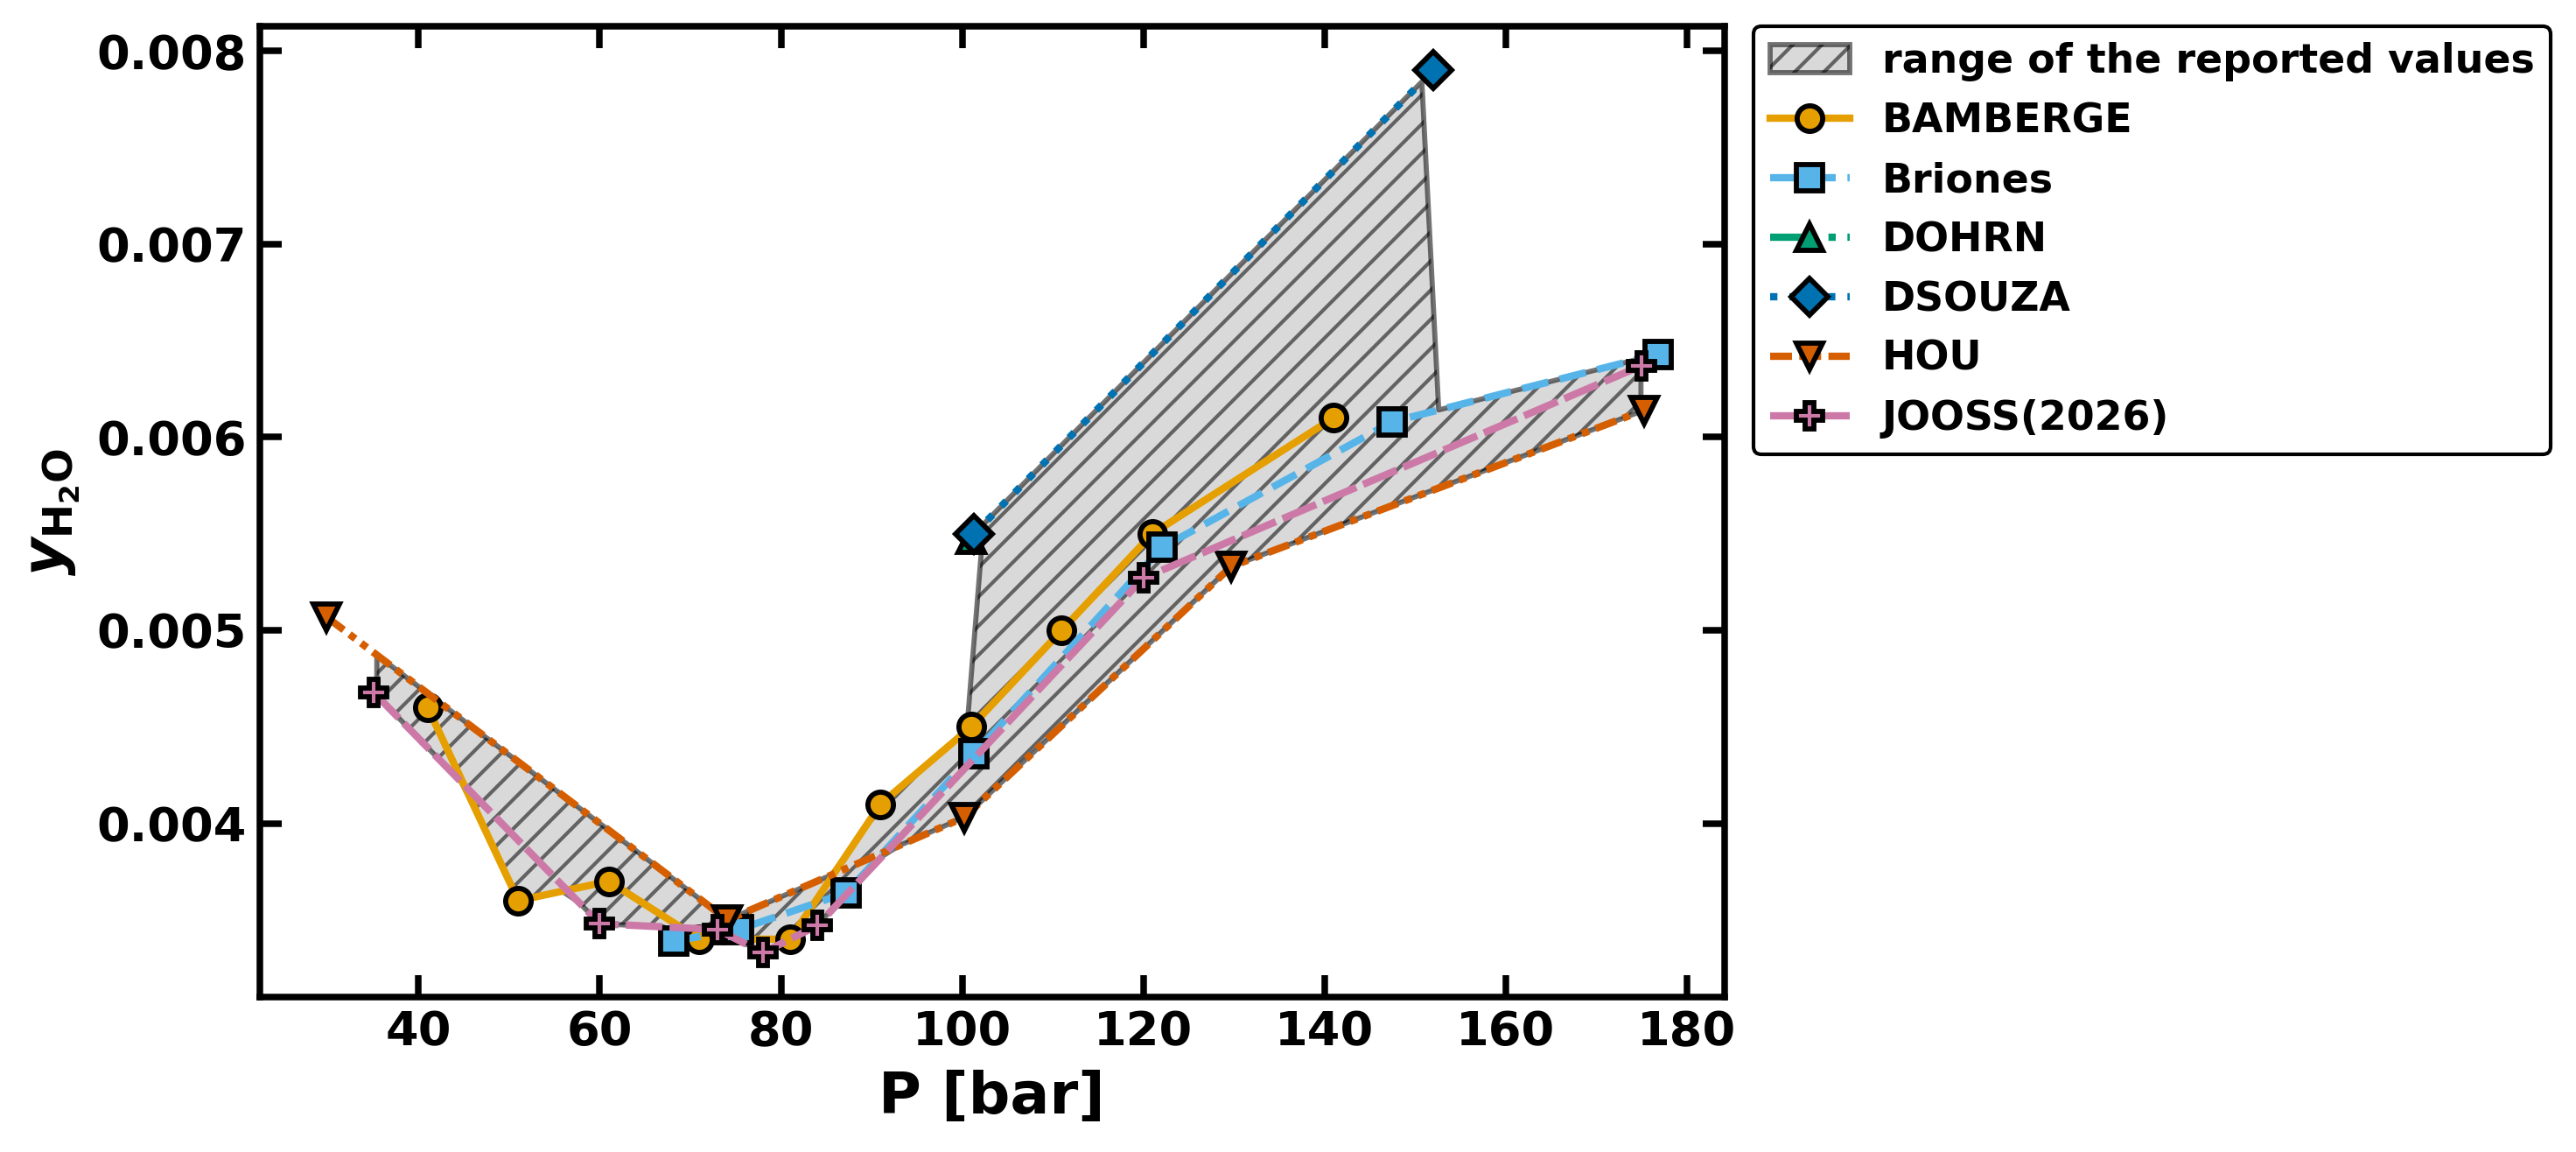

In [22]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

sub = gbb.select(df, property="y_h2o", gas="co2", salt_free=True,
                 T=(321.5, 324.5), P=(20, 180))
draw_envelope(ax, *envelope(sub, "P_bar", "value"))
for i, (src, g) in enumerate(sub.groupby("source")):
    g = g.sort_values("P_bar")
    ax.plot(g["P_bar"], g["value"], **series_style(i),
            markeredgecolor="black", markersize=7, linewidth=2.0, label=src)

label(ax, "P [bar]", r"$y_{\mathrm{H_2O}}$")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.show()

### Figure 10 -- CO$_2$ solubility in 1 mol/kg NaCl at 373 K

The same picture for a solubility in a brine rather than a water content in a
gas: six sources, one temperature, one salinity. The envelope is widest at
the low-pressure end, where the measurement is hardest -- a small absolute
error in the equilibrium pressure moves the solubility a long way up the
steep part of the isotherm.

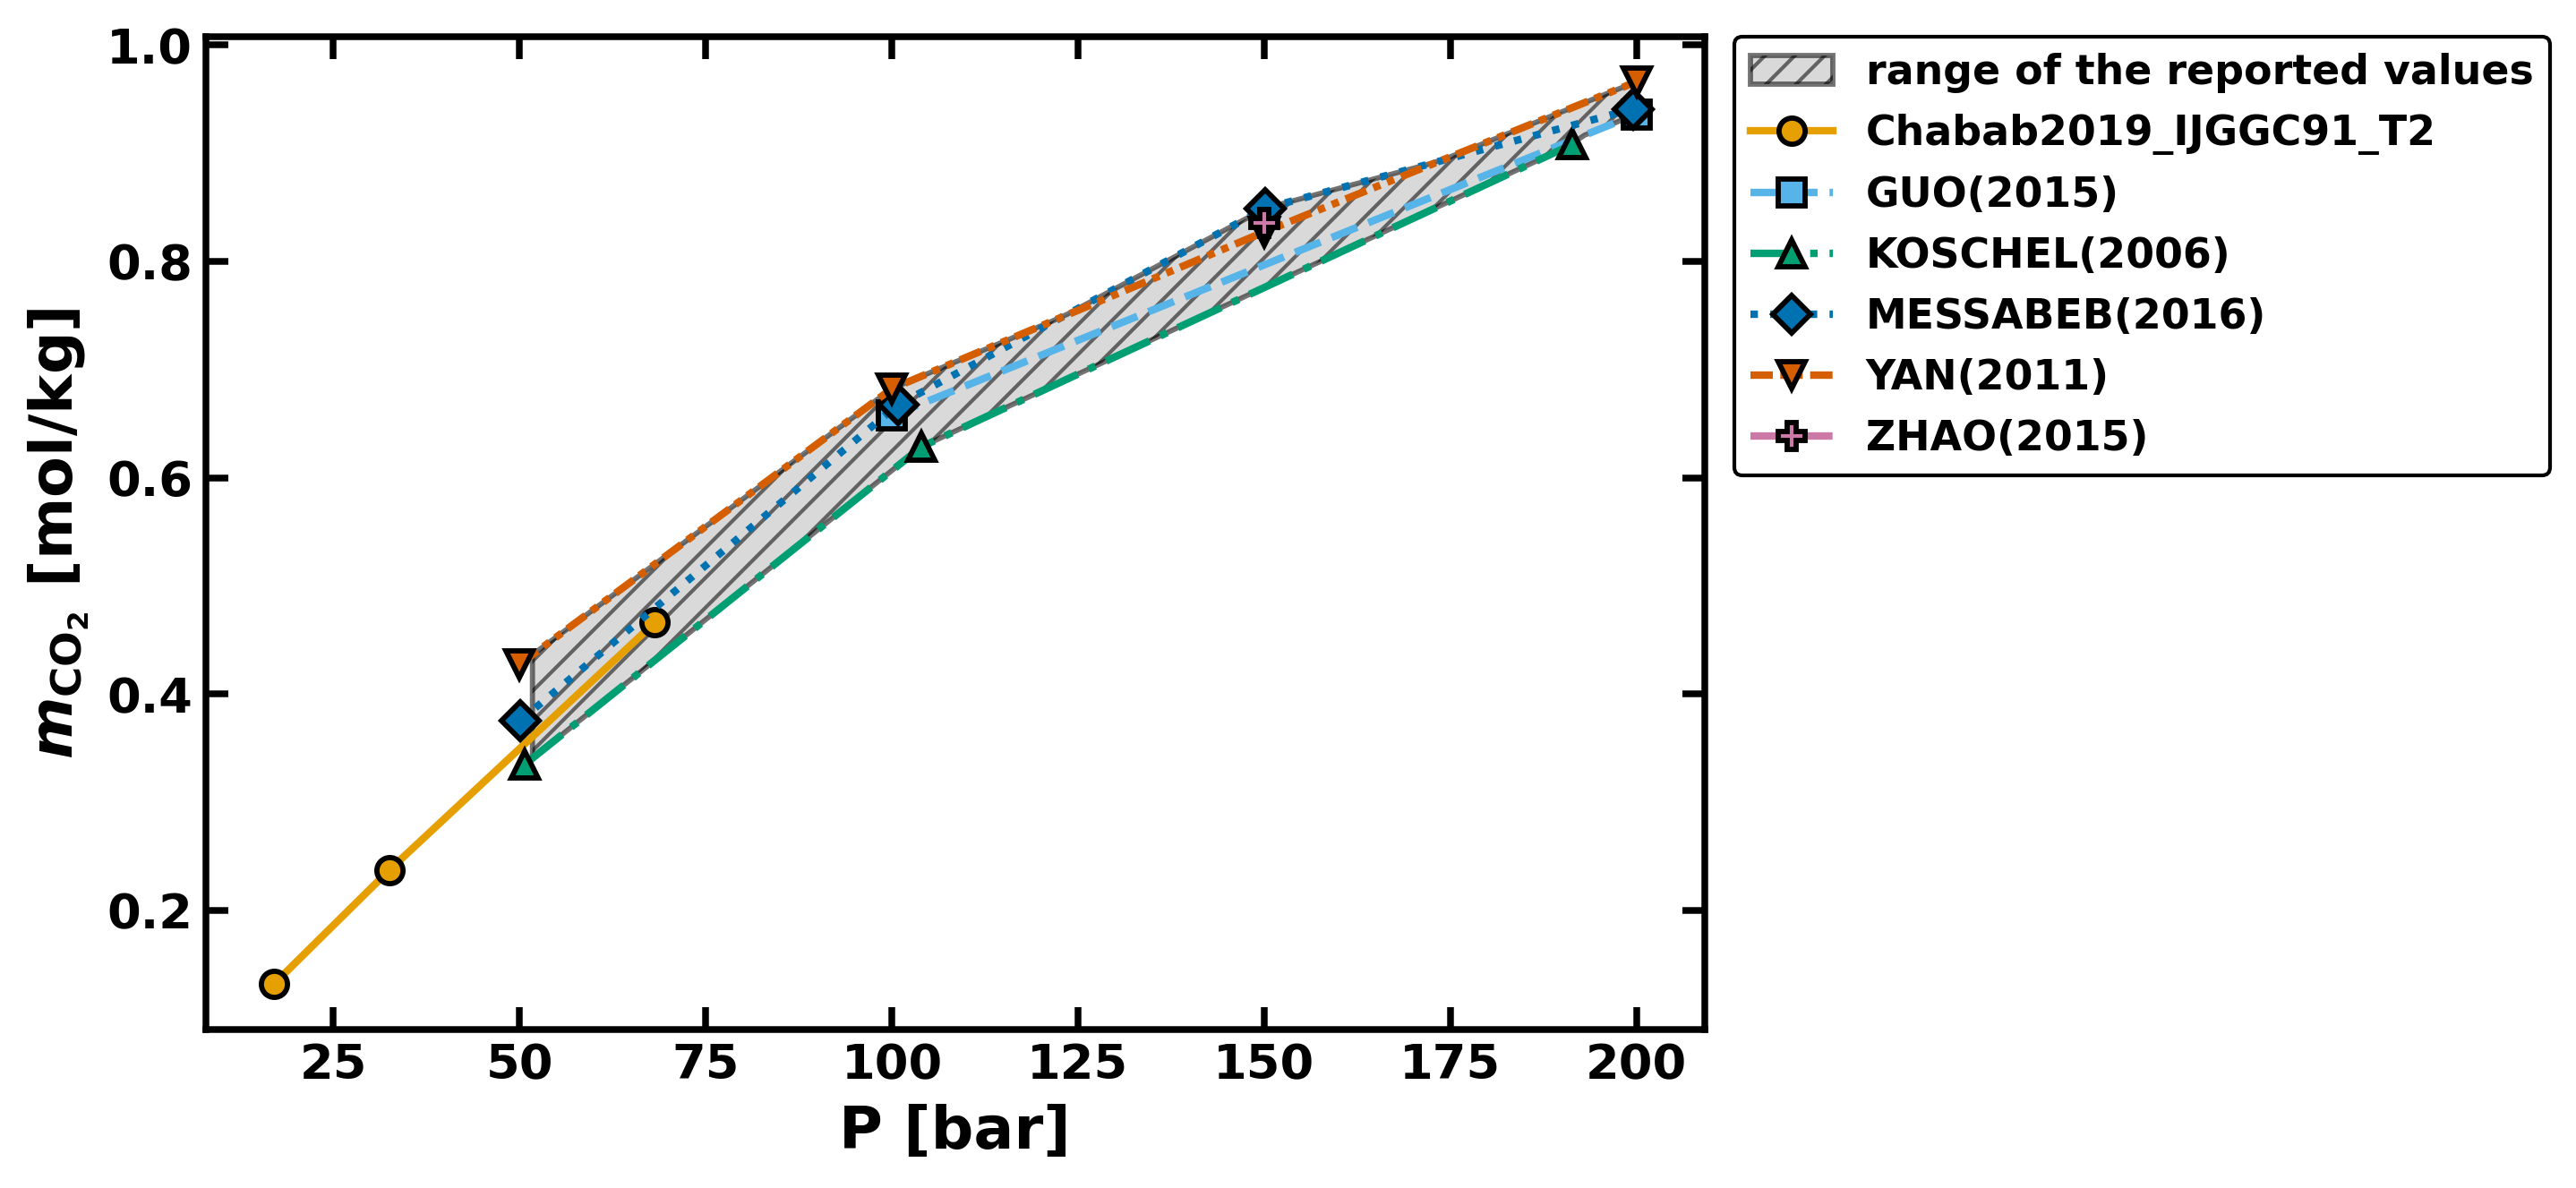

In [23]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

sub = sol[(sol["gas"] == "co2") & (sol["salt_system"] == "Na-Cl")
          & (sol["m_Na"].between(0.95, 1.05))
          & (sol["T_K"].between(371.5, 374.5))
          & (sol["P_bar"] <= 220)]
draw_envelope(ax, *envelope(sub, "P_bar", "solubility_molality"))
for i, (src, g) in enumerate(sub.groupby("source")):
    g = g.sort_values("P_bar")
    ax.plot(g["P_bar"], g["solubility_molality"], **series_style(i),
            markeredgecolor="black", markersize=7, linewidth=2.0, label=src)

label(ax, "P [bar]", r"$m_{\mathrm{CO_2}}$ [mol/kg]")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.show()

---

## 7. The brine properties

### Figure 11 -- density

The gas-free families are what pin down the brine itself, without which a
solubility model has nothing to be a correction to. Panel (a): density
against total ion molality at 373 K and 100 bar, for the five single-salt
systems. Panel (b): the pressure dependence at 298 K, for three NaCl
molalities -- a few per cent over 700 bar, small but far from negligible at
storage conditions.

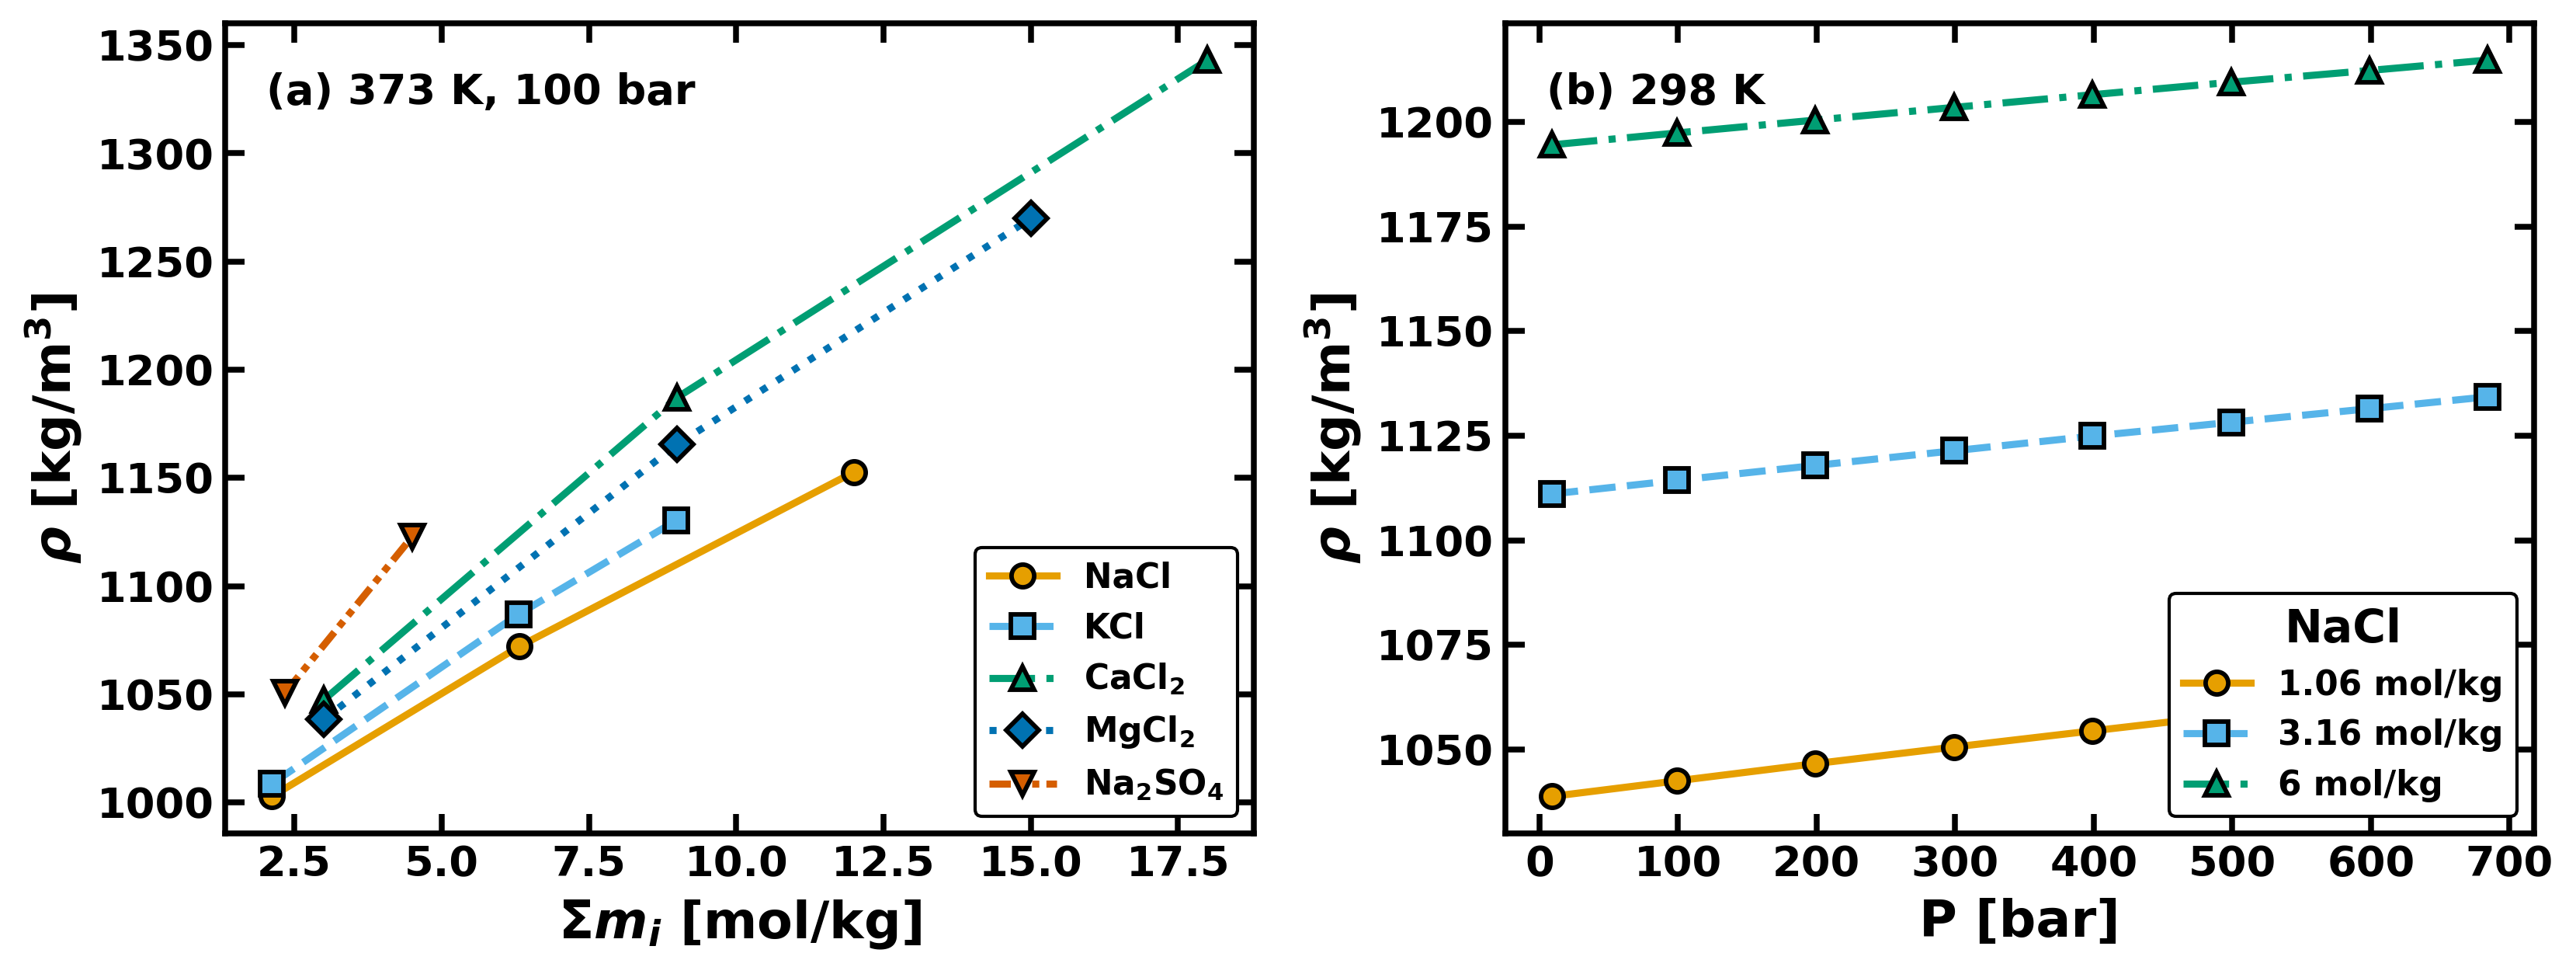

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
rho = gbb.load("rho")

ax = axes[0]
sub = rho[(rho["T_K"] == 373) & (rho["P_bar"].between(90, 110))]
for i, sysname in enumerate(["Na-Cl", "Cl-K", "Cl-Ca", "Cl-Mg", "Na-SO4"]):
    s = sub[sub["salt_system"] == sysname].sort_values("total_molality")
    ax.plot(s["total_molality"], s["value"], **series_style(i),
            markeredgecolor="black", label=SALT_LABEL[sysname])
label(ax, r"$\Sigma m_i$ [mol/kg]", r"$\rho$ [kg/m$^3$]")
ax.legend(loc="lower right", fontsize=10.5)
ax.text(0.04, 0.94, "(a) 373 K, 100 bar", transform=ax.transAxes,
        fontweight="bold", fontsize=13, va="top")

ax = axes[1]
sub = rho[(rho["salt_system"] == "Na-Cl") & (rho["T_K"] == 298)]
for i, m in enumerate(sorted(set(sub["m_Na"]))):
    s = sub[sub["m_Na"] == m].sort_values("P_bar")
    ax.plot(s["P_bar"], s["value"], **series_style(i),
            markeredgecolor="black", label=f"{m:g} mol/kg")
label(ax, "P [bar]", r"$\rho$ [kg/m$^3$]")
ax.legend(loc="lower right", title="NaCl", fontsize=10.5,
          title_fontproperties={"weight": "bold"})
ax.text(0.04, 0.94, "(b) 298 K", transform=ax.transAxes,
        fontweight="bold", fontsize=13, va="top")

fig.tight_layout()
plt.show()

### Figure 12 -- osmotic coefficients

Water activity, as the osmotic coefficient $\phi$, for the same five salts at
298.15 K on a logarithmic ionic-strength axis. All five start near the
Debye-Huckel limit and then part company: the chlorides turn up, sharply for
the divalent cations, while Na$_2$SO$_4$ keeps falling. This is the property
that fixes the activity of *water* in the brine, and it constrains the same
ion-water interactions the solubility curves in Figures 6 and 7 do -- from a
measurement that involves no gas at all.

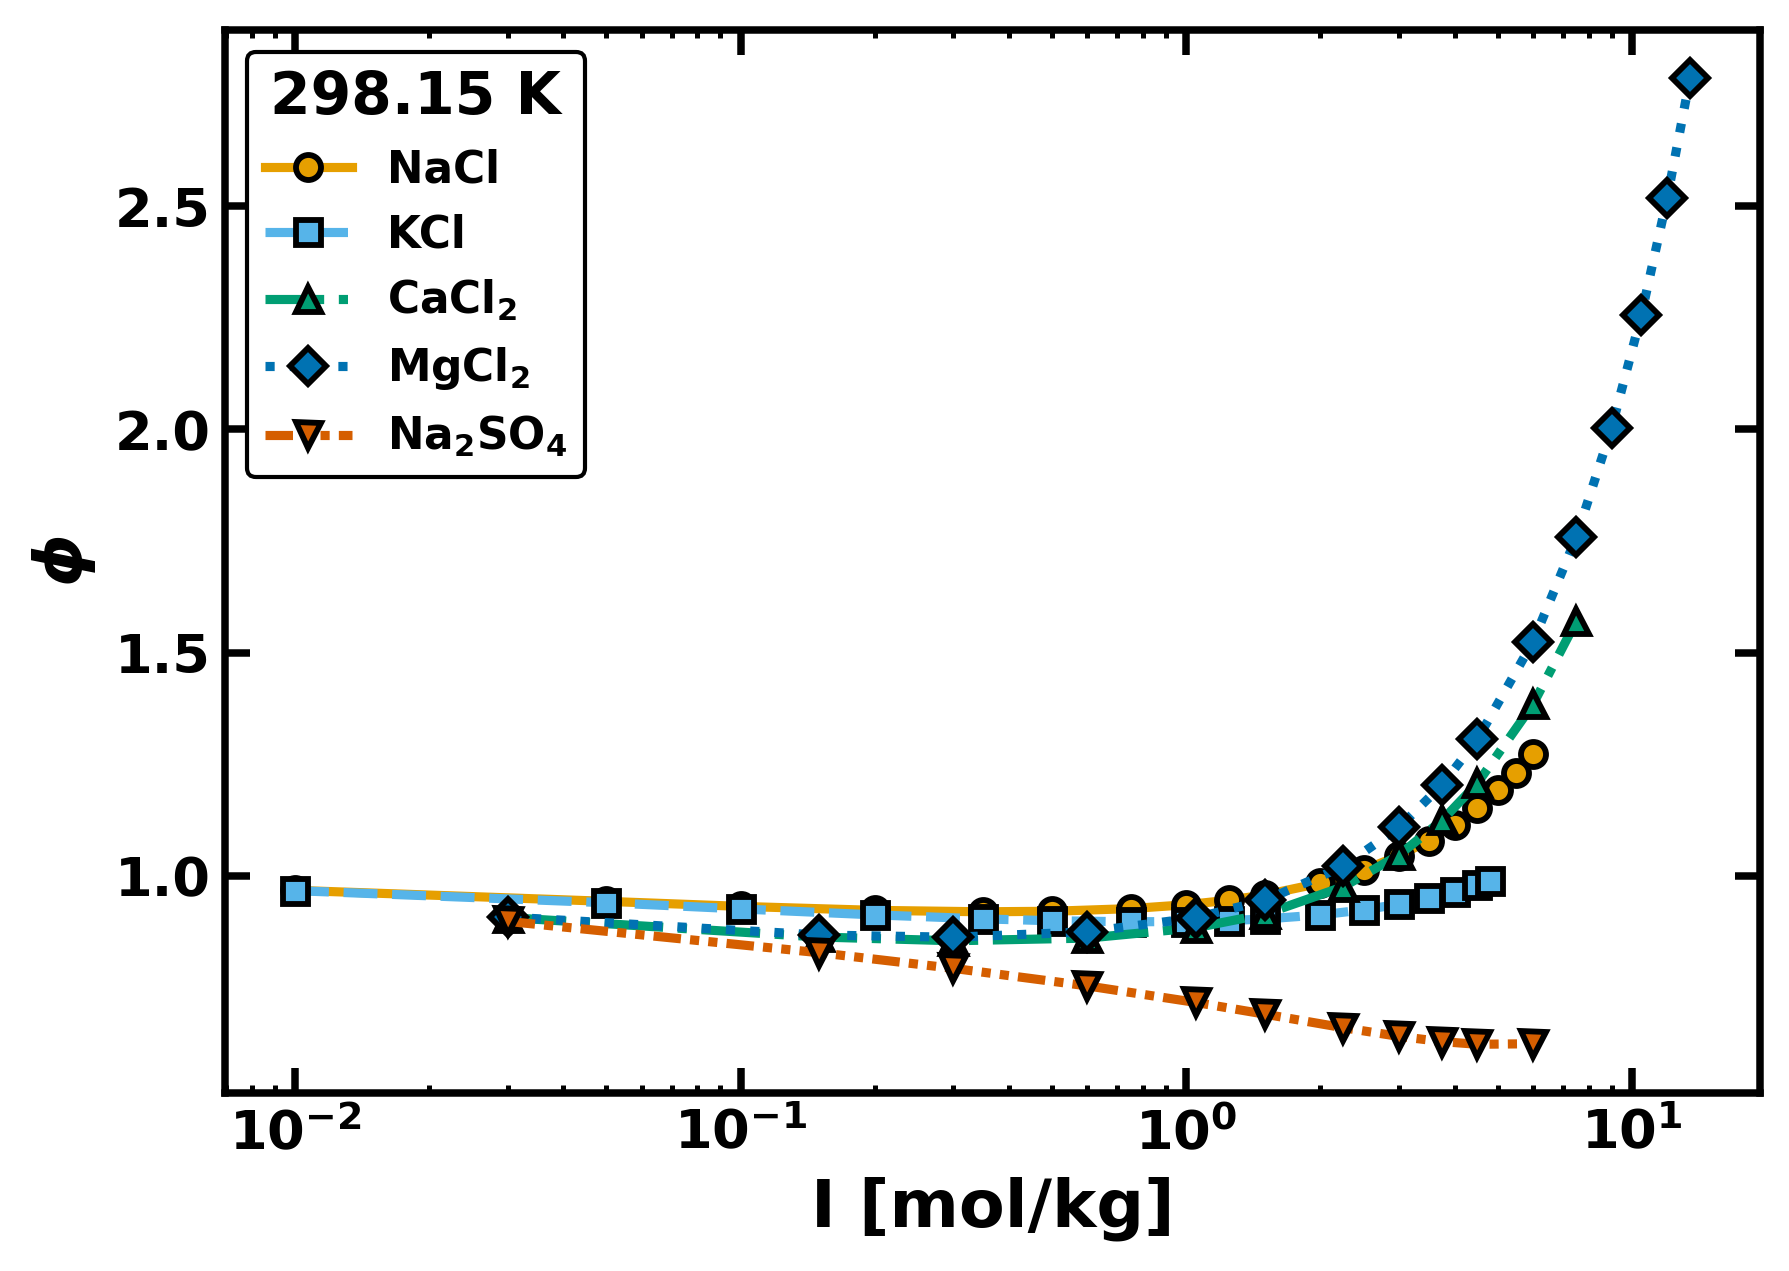

In [25]:
fig, ax = plt.subplots()

po = gbb.load("phi_osm")
sub = po[po["T_K"] == 298.15]
for i, sysname in enumerate(["Na-Cl", "Cl-K", "Cl-Ca", "Cl-Mg", "Na-SO4"]):
    s = sub[sub["salt_system"] == sysname].sort_values("ionic_strength")
    if not len(s):
        continue
    ax.plot(s["ionic_strength"], s["value"], **series_style(i),
            markeredgecolor="black", markersize=6, label=SALT_LABEL[sysname])

ax.set_xscale("log")
label(ax, "I [mol/kg]", r"$\phi$")
ax.legend(loc="upper left", title="298.15 K", fontsize=10.5,
          title_fontproperties={"weight": "bold"})
plt.show()

---

## 8. Export

`gbb.write()` picks the format from the file-name suffix: `.csv`,
`.parquet` / `.pq`, `.h5` / `.hdf5` / `.hdf`. CSV needs nothing beyond
pandas. Parquet needs `pyarrow` and HDF5 needs `tables`, and if either is
missing you get a `MissingDependencyError` that names the one package to
install -- checked *before* pandas is reached, so a missing backend never
arrives disguised as something else.

In [26]:
import tempfile

tmp = Path(tempfile.mkdtemp())          # nothing is written into the clone
subset = gbb.load("solubility", gas="co2", quality="R")

print(f"exporting {len(subset):,} rows\n")
for name in ["co2_recommended.csv", "co2_recommended.parquet",
             "co2_recommended.h5"]:
    try:
        p = gbb.write(subset, tmp / name)
        print(f"  {name:<26} {p.stat().st_size / 1024:8.1f} kB")
    except gbb.MissingDependencyError as exc:
        print(f"  {name:<26} not written --")
        print("     ", str(exc).splitlines()[0])

exporting 149 rows

  co2_recommended.csv            21.3 kB
  co2_recommended.parquet        15.9 kB
  co2_recommended.h5             83.2 kB


This is what you get when a backend is absent. The check is on the package,
by name, before pandas is involved -- so a missing `pyarrow` never arrives
disguised as an engine-resolution failure, and a missing `tables` never
arrives as an `AttributeError` from somewhere inside `to_hdf`.

In [27]:
import importlib.util

real_find_spec = importlib.util.find_spec
try:
    # Pretend pyarrow is not installed.
    importlib.util.find_spec = (
        lambda name, *a, **k: None if name == "pyarrow"
        else real_find_spec(name, *a, **k)
    )
    gbb.write(subset, tmp / "nope.parquet")
except gbb.MissingDependencyError as exc:
    print(f"{type(exc).__name__} (a subclass of ImportError):\n")
    print(exc)
finally:
    importlib.util.find_spec = real_find_spec

MissingDependencyError (a subclass of ImportError):

writing Parquet needs the 'pyarrow' package, which is not installed. Install it with:  pip install pyarrow
GasBrineBench itself needs only pandas; CSV export always works.


In [28]:
# Availability of the optional backends in this environment.
pd.DataFrame(
    [{"format": f, "backend": b, "available": gbb.export.have(f)}
     for f, b in [("csv", "pandas"), ("parquet", "pyarrow"),
                  ("hdf5", "tables")]]
).set_index("format")

,backend,available
format,,
csv,pandas,True
parquet,pyarrow,True
hdf5,tables,True


In [29]:
# CSV round-trips: blanks stay blank, the empty gas cell stays an empty
# string, and the file reloads through the package's own loader.
p = gbb.write(gbb.load("psat_ratio"), tmp / "psat_ratio.csv")
back = gbb.load_family("psat_ratio", where=tmp)
print("round-tripped rows :", len(back))
print("blank P_bar kept   :", bool(back["P_bar"].isna().all()))
print("'NaN' in the file  :", "NaN" in p.read_text())

round-tripped rows : 21
blank P_bar kept   : True
'NaN' in the file  : False


## 9. Speciation codes: PHREEQC, Geochemist's Workbench

**No native exporter is provided, on purpose.** The brine half of a row maps
onto a PHREEQC `SOLUTION` block cleanly, and `gasbrinebench.interop`
tabulates that mapping. The other half does not.

To reproduce one of these measurements, a speciation code needs the
*gas-phase boundary condition*: a fugacity or a partial pressure. The
database stores the **total** pressure of the experiment, as the sources
report it. Converting one into the other requires a water-content model and a
fugacity coefficient -- that is, an equation of state -- which are precisely
the modelling steps a gas-solubility benchmark exists to test. An exporter
would have to choose both, bake the choice into the file, and hand you a
number that looks like data; any later disagreement between PHREEQC and the
measurement would then be partly an artefact of the converter's own
assumptions, with nothing in the file to say so.

Two smaller obstacles point the same way: PHREEQC needs a pH, which these
experiments do not report and a CO$_2$-charged brine sets for itself; and the
databases that cover this pressure range at all have stated validity limits
well inside the 0.1-3,500 bar span of these rows.

So the mapping is documented and the decision is left to you. For
Geochemist's Workbench not even that is asserted -- its input-script
specification was not consulted, and writing down a file format from memory
is the same mistake in a different costume.

In [30]:
mapping = pd.DataFrame(
    [{"GasBrineBench column": k, "PHREEQC SOLUTION entry": v}
     for k, v in gbb.phreeqc_column_map().items()]
).set_index("GasBrineBench column")

print("Concentrations transfer unchanged under `units mol/kgw`.\n")
print("Everything else that a SOLUTION block needs:")
for k, v in gbb.interop.PHREEQC_NOTES.items():
    print(f"  {k:<8} {v}")
print()
mapping

Concentrations transfer unchanged under `units mol/kgw`.

Everything else that a SOLUTION block needs:
  T_K      temp = T_K - 273.15 (PHREEQC reads degrees Celsius)
  P_bar    pressure = P_bar / 1.01325 (PHREEQC reads atmospheres)
  units    units mol/kgw
  water    -water 1.0 (molalities are per kg of water)
  pH       not in the database; the user must choose and justify one
  gas      not exportable without a model: the database stores TOTAL pressure, and a GAS_PHASE block needs a fugacity, which requires a water-content model and an equation of state



,PHREEQC SOLUTION entry
GasBrineBench column,
m_Na,Na
m_K,K
m_Ca,Ca
m_Mg,Mg
m_Cl,Cl
m_SO4,S(6)


---

## 10. From the shell

The package has a small command-line front end for the two things you want
without opening Python -- an inventory, and a filtered export:

```
python3 -m gasbrinebench                     # inventory by family
python3 -m gasbrinebench --by gas            # inventory by gas
python3 -m gasbrinebench --gas co2 --quality R -o co2.csv
python3 -m gasbrinebench --family solubility -o solubility.parquet
```

## Where to go next

| you want | look at |
|---|---|
| the row schema and the `tag` vocabulary | `SCHEMA.md` |
| where a block of rows came from: paper, table, page | `data/README.md` |
| why a row carries the quality code it does | `data/QUALITY.md` |
| the reference and DOI behind a `source` cell | `SOURCES.md`, `SOURCES.bib` |
| every correction and deduplication, with its reason | `LEDGER.md` |
| the hand transcriptions the values were typed from | `transcriptions/` |
| the full API | the docstrings: `help(gasbrinebench)` |

## Citing

Cite **the original experimental sources** for the numbers you use --
`SOURCES.md` gives the reference and DOI for each -- and cite the repository
for the compilation. A Zenodo version DOI and a data-descriptor reference
will be added at the v1.0 release; see `CITATION.cff`.

The numerical values in this database are measurements made and published by
the authors named in `SOURCES.md`. They are the people to credit.